# PROYECTO FINAL JUNIOR SCHOOL
**Luis Alex Farfan**

In [19]:
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score
from sklearn.neighbors import LocalOutlierFactor
import time
import missingno as msno
from sklearn.impute import KNNImputer 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_regression

## Carga de datos

In [20]:
dataset = pd.read_csv('insurance_claims.csv',na_values='?')

#dataset =dataset_df.drop(['policy_number','policy_bind_date','incident_location','incident_date','auto_model','auto_year','insured_hobbies','insured_occupation','auto_make', '_c39'],axis=1)
dataset

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,NaN,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,NaN,0,0,NaN,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,NaN,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,NaN,Minor Damage,None,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,FEMALE,Masters,craft-repair,paintball,unmarried,0,0,2015-02-22,Single Vehicle Collision,Front Collision,Minor Damage,Fire,NC,Northbrook,6045 Andromedia St,20,1,YES,0,1,NaN,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,FEMALE,PhD,prof-specialty,sleeping,wife,70900,0,2015-01-24,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbend,3092 Texas Drive,23,1,YES,2,3,NaN,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,FEMALE,Masters,armed-forces,bungie-jumping,other-relative,35100,0,2015-01-23,Multi-vehicle Collision,Side Collision,Minor Damage,Police,NC,Arlington,7629 5th St,4,3,NaN,2,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,MALE,Associate,handlers-cleaners,base-jumping,wife,0,0,2015-02-26,Single Vehicle Collision,Rear Collision,Major Damage,Other,NY,Arlington,6128 Elm Lane,2,1,NaN,0,1,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN


In [21]:
dataset['fraud_reported']=dataset['fraud_reported'].apply(lambda x:1 if x=='Y' else 0)
dataset

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,1,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,NaN,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,NaN,0,0,NaN,5070,780,780,3510,Mercedes,E400,2007,1,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,0,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,NaN,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,NaN,Minor Damage,None,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,FEMALE,Masters,craft-repair,paintball,unmarried,0,0,2015-02-22,Single Vehicle Collision,Front Collision,Minor Damage,Fire,NC,Northbrook,6045 Andromedia St,20,1,YES,0,1,NaN,87200,17440,8720,61040,Honda,Accord,2006,0,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,FEMALE,PhD,prof-specialty,sleeping,wife,70900,0,2015-01-24,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbend,3092 Texas Drive,23,1,YES,2,3,NaN,108480,18080,18080,72320,Volkswagen,Passat,2015,0,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,FEMALE,Masters,armed-forces,bungie-jumping,other-relative,35100,0,2015-01-23,Multi-vehicle Collision,Side Collision,Minor Damage,Police,NC,Arlington,7629 5th St,4,3,NaN,2,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,0,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,MALE,Associate,handlers-cleaners,base-jumping,wife,0,0,2015-02-26,Single Vehicle Collision,Rear Collision,Major Damage,Other,NY,Arlington,6128 Elm Lane,2,1,NaN,0,1,YES,46980,5220,5220,36540,Audi,A5,1998,0,NaN


###Histogramas de los datos

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f111ac523d0>,
      dtype=object)

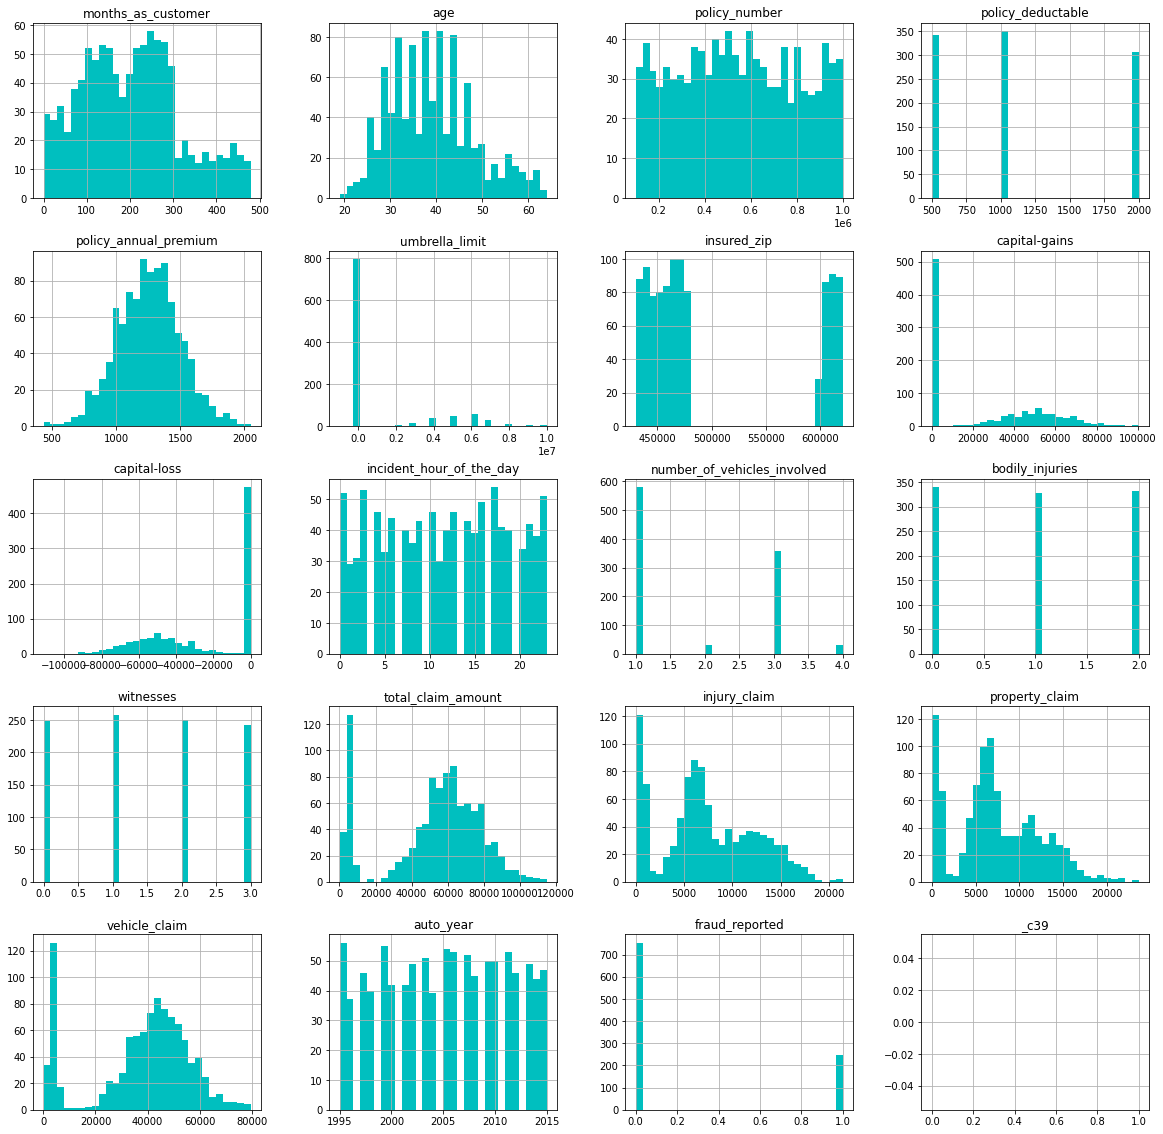

In [22]:
#Dibujamos histograma
dataset.hist(bins=30, figsize=(20,20),color='c')

Podemos observar como hay algunas variables que se distribuyen de manera aproximada a una distribución normal por ejemplo "age" o "total_claim_amount". Adicionalmente, se verifica que nuestro conjunto de datos, es un conjunto desbalanceado ya que nuestra variable a predecir "fraud_reported" tiene muchos más casos donde "frad_reported" es no (0) respecto a los casos dónde sí hay fraude (1).



## Limpieza de datos

###Eliminación de columnas repetidas y duplicadas

Vamos a hacer un análisis previo para buscar posibles columnas duplicadas y también para hallar posibles columnas superfluas que no aporten información a nuestro problema. Para ello empezamos creando una tabla para ver cuantos registros diferentes tiene cada columna. 

In [23]:
#Mostrar columnas con sus diferentes valores

print(dataset.nunique(dropna=False).sort_values(ascending=False))

policy_number                  1000
incident_location              1000
insured_zip                     995
policy_annual_premium           991
policy_bind_date                951
total_claim_amount              763
vehicle_claim                   726
injury_claim                    638
property_claim                  626
months_as_customer              391
capital-loss                    354
capital-gains                   338
incident_date                    60
age                              46
auto_model                       39
incident_hour_of_the_day         24
auto_year                        21
insured_hobbies                  20
insured_occupation               14
auto_make                        14
umbrella_limit                   11
insured_education_level           7
incident_state                    7
incident_city                     7
insured_relationship              6
authorities_contacted             5
collision_type                    4
incident_type               

In [24]:
print('Dimensión original del dataframe: {}'.format(dataset.shape))
# Guardamos el número único de valores para cada columna en una variable
counts = dataset.nunique(dropna=False)
# Almacenamos las columnas a borrar
to_del = [i for i,v in enumerate(counts) if v == 1]
print('Columnas a borrar: {}'.format(to_del))
# Borramos las columnas innecesarias
dataset.drop(dataset.columns[to_del], axis=1, inplace=True)
print('Dimensión final del dataframe: {}'.format(dataset.shape))
dataset

Dimensión original del dataframe: (1000, 40)
Columnas a borrar: [39]
Dimensión final del dataframe: (1000, 39)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,1
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,NaN,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,NaN,0,0,NaN,5070,780,780,3510,Mercedes,E400,2007,1
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,0
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,NaN,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,NaN,Minor Damage,None,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,FEMALE,Masters,craft-repair,paintball,unmarried,0,0,2015-02-22,Single Vehicle Collision,Front Collision,Minor Damage,Fire,NC,Northbrook,6045 Andromedia St,20,1,YES,0,1,NaN,87200,17440,8720,61040,Honda,Accord,2006,0
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,FEMALE,PhD,prof-specialty,sleeping,wife,70900,0,2015-01-24,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbend,3092 Texas Drive,23,1,YES,2,3,NaN,108480,18080,18080,72320,Volkswagen,Passat,2015,0
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,FEMALE,Masters,armed-forces,bungie-jumping,other-relative,35100,0,2015-01-23,Multi-vehicle Collision,Side Collision,Minor Damage,Police,NC,Arlington,7629 5th St,4,3,NaN,2,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,0
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,MALE,Associate,handlers-cleaners,base-jumping,wife,0,0,2015-02-26,Single Vehicle Collision,Rear Collision,Major Damage,Other,NY,Arlington,6128 Elm Lane,2,1,NaN,0,1,YES,46980,5220,5220,36540,Audi,A5,1998,0


Observamos si existe algún registro duplicado en nuestro dataset.

In [25]:
# Calculamos los duplicados
dups = dataset.duplicated()
#dups me devuelve serie con false,false,false,false...false

# Miramos si hay duplicados
print('Algun duplicado? {}'.format(dups.any()))
# Sacamos la lista de duplicados
print('Registros duplicados: \n{}'.format(dataset[dups]))

Algun duplicado? False
Registros duplicados: 
Empty DataFrame
Columns: [months_as_customer, age, policy_number, policy_bind_date, policy_state, policy_csl, policy_deductable, policy_annual_premium, umbrella_limit, insured_zip, insured_sex, insured_education_level, insured_occupation, insured_hobbies, insured_relationship, capital-gains, capital-loss, incident_date, incident_type, collision_type, incident_severity, authorities_contacted, incident_state, incident_city, incident_location, incident_hour_of_the_day, number_of_vehicles_involved, property_damage, bodily_injuries, witnesses, police_report_available, total_claim_amount, injury_claim, property_claim, vehicle_claim, auto_make, auto_model, auto_year, fraud_reported]
Index: []


In [26]:
#Borramos registros duplicados
print('Dimensión original del dataframe: {}'.format(dataset.shape))
# delete duplicate rows
dataset.drop_duplicates(inplace=True)
print('Dimensión final del dataframe: {}'.format(dataset.shape))

Dimensión original del dataframe: (1000, 39)
Dimensión final del dataframe: (1000, 39)


En la tabla donde salen ordenadas las columnas en función del número de elementos diferentes por columna, se puede observar como hay variables que no aportan información a nuestro estudio ya que aportan un dato diferente para cada registro. Estas columnas son policy_number, insured_zip,policy_bind_date y incident_location. Por otra parte incident_date solo cuenta con fechas correspondientes a enero y febrero y por lo tanto al no estar distribuida por todos los meses, tampoco aporta información. Por esta razón resulta conveniente eliminarlas antes de continuar con las siguientes etapas.

In [27]:
#Eliminar algunas columnas superfluas en base al nunique de antes
dataset=dataset.drop(['policy_number','policy_bind_date','insured_zip','incident_location','incident_date'],axis=1)
dataset.shape 
#incident date -reclasificar 

#Columnas superfluas policy_number, policy_bind_date,incident_location,incident_date,auto_model,auto_year,insured_hobbies, insured_occupation,auto_make
#dataset=dataset_df5.drop(['policy_number','policy_bind_date','incident_location','incident_date','auto_model','auto_year','insured_hobbies','insured_occupation','auto_make'],axis=1)

(1000, 34)

### Missing data

Antes de eliminar o imputar los missing values de este dataset, se han analizado usando la librería missingno.

En primer lugar se ha obtenido una matriz para visualizar la presencia de los missing values. De esta forma se puede determinar si existe algún patrón en la aparición de estos valores en distintas variables. 

En este caso se ha podido observar como solo se tienen missing values en tres variables: collision_type, property_damage y police_report. No siguen un patrón similar en ningúno de los casos:

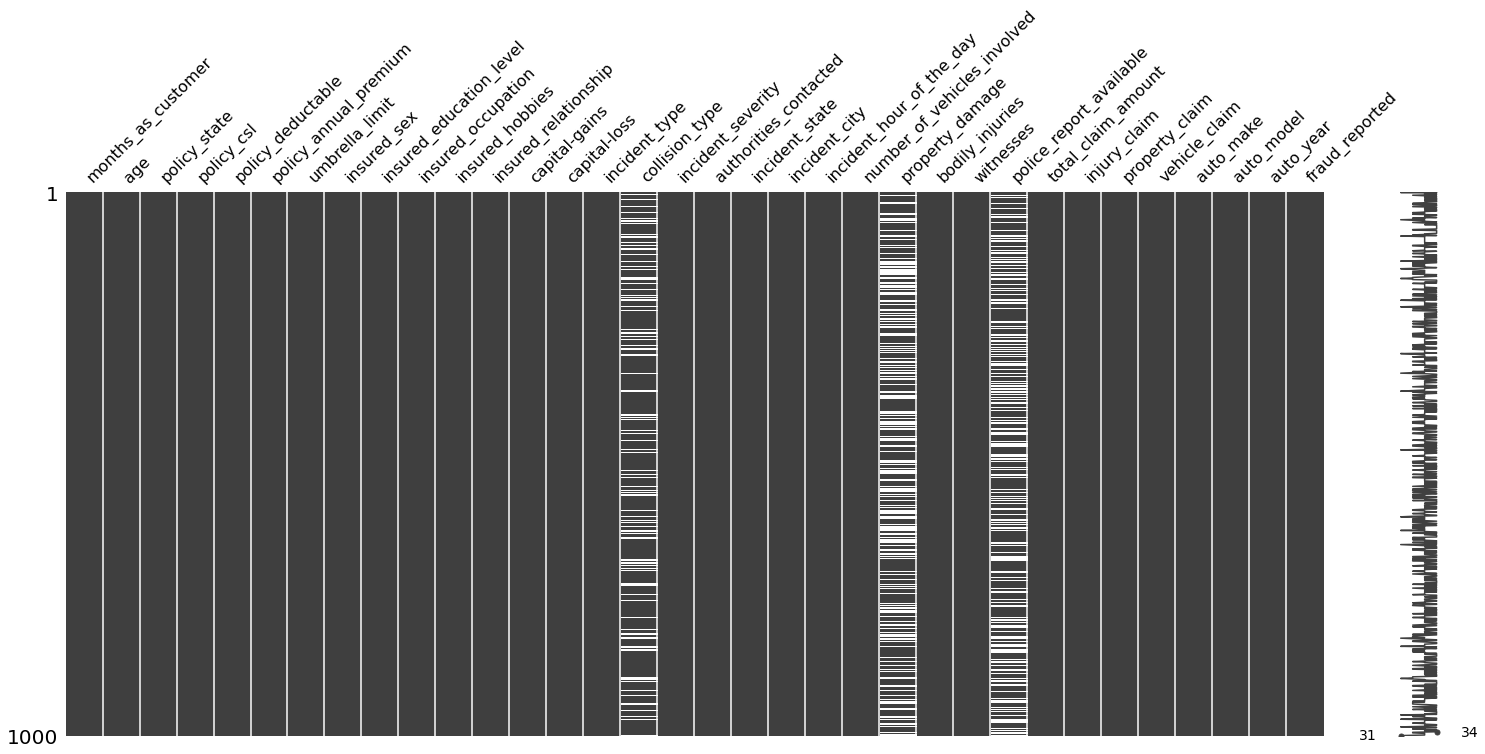

In [28]:
msno.matrix(dataset)

A continuación se ha obtenido un gráfico de barras con el número de missing values de cada variable. De esta forma se ha podido confirmar que estos valores tan solo aparecen en las tres variables esmentadas anteriormente, con unos 200-400 missing values cada una.

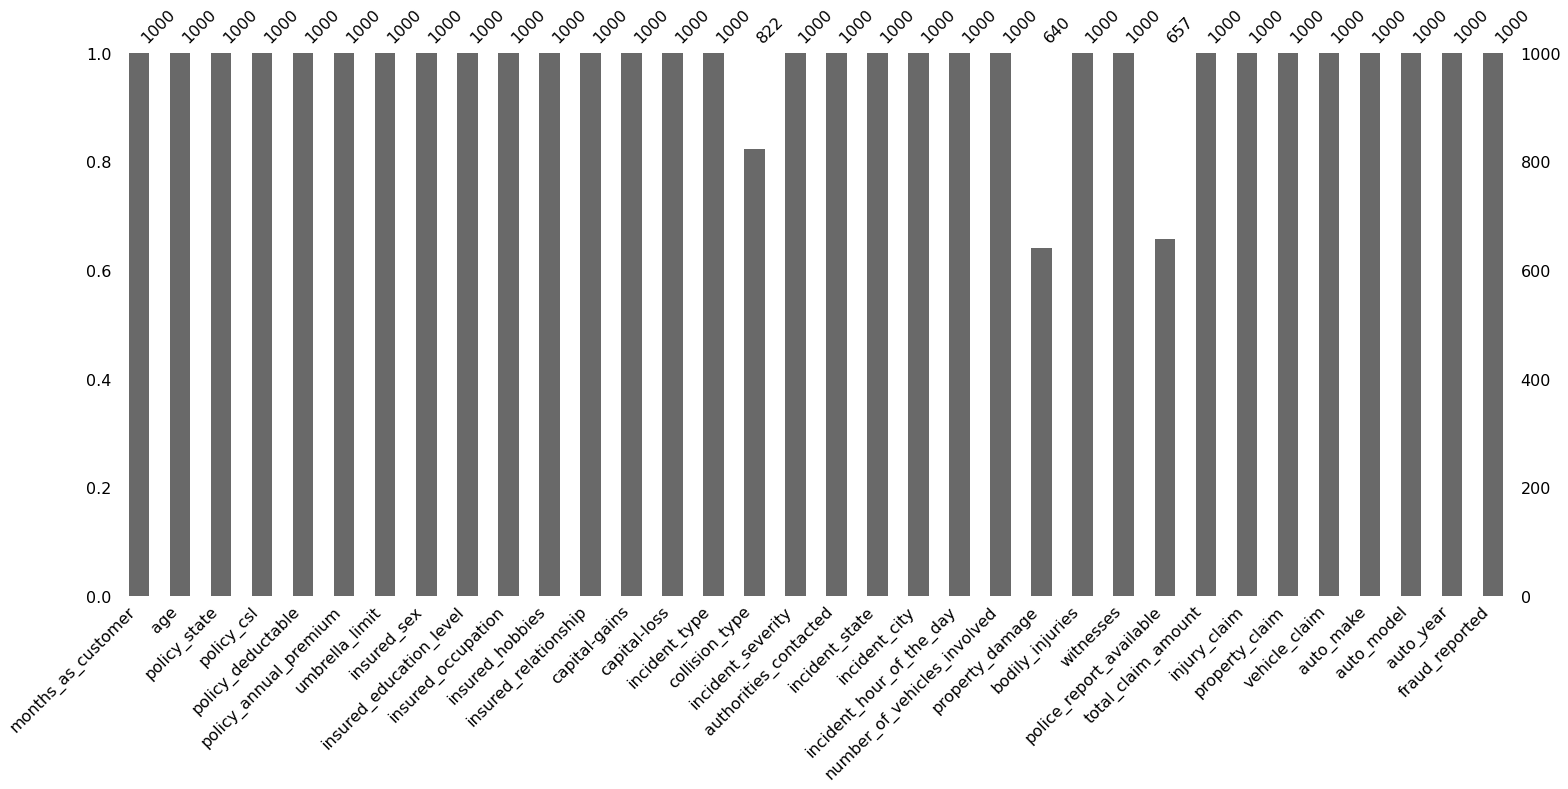

In [29]:
msno.bar(dataset)

Finalmente se ha visualizado el heatmap de las variables que contienen missing values, para determinar si existe alguna correlación en estos valores.

Como se puede observar a continuación, los missing values de estas variables no estan correlados.

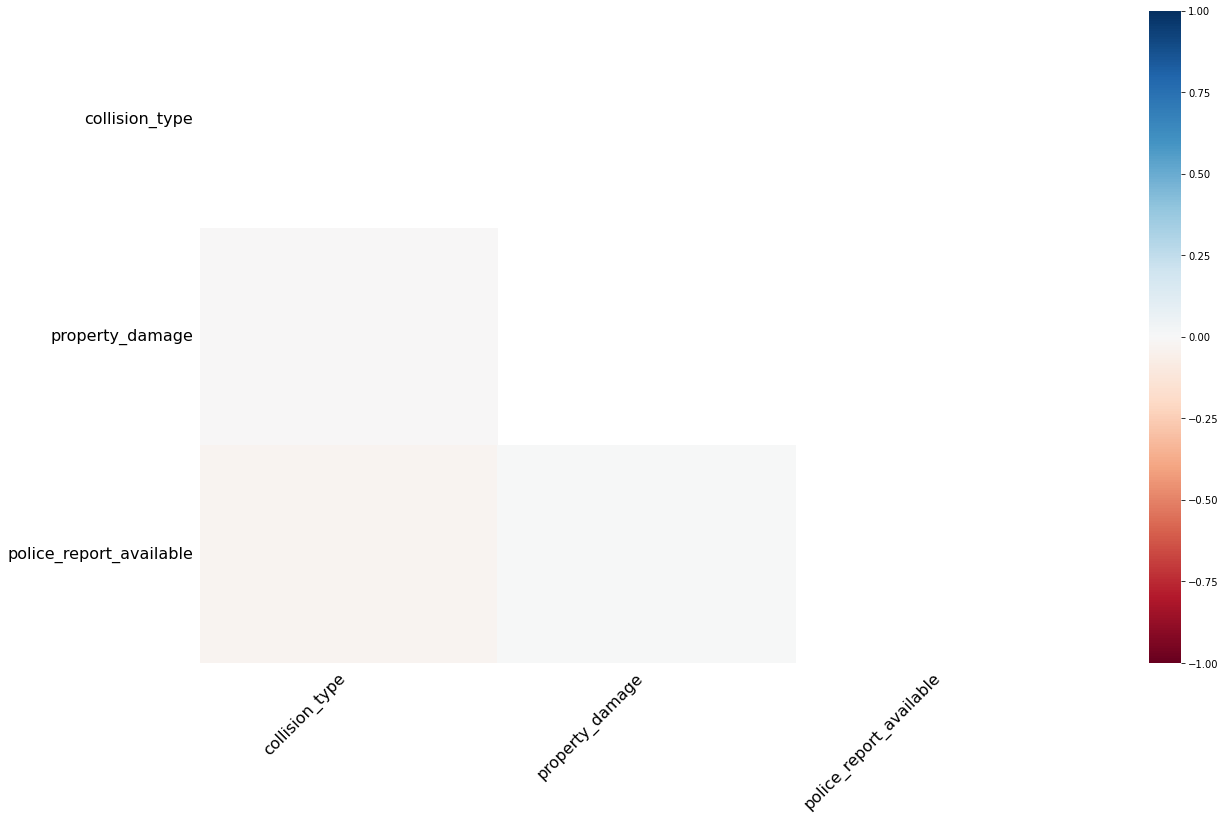

In [30]:
msno.heatmap(dataset)

### Conversión valores categóricos

Para realizar la imputación de los missing values se han convertido los valores categóricos a numéricos.

In [31]:
#distingim les columnes categoriques de les columnes numeriques
le_count = 0
categorie_count=0
categorical_columns=[]
name_columns=[]
numerical_columns=[]
name_columns_numerical=[]
# iterem en totes les columnes
for col in dataset:
    if dataset[col].dtype == 'object':
        # obtenim una llista amb l'index de totes les columnes categoriques
        categorical_columns.append(dataset.columns.get_loc(col))
        name_columns.append(col)
        categorie_count=categorie_count+dataset[col].nunique()
        le_count += 1
    else:
        # obtenim una llista amb l'index de totes les columnes numeriques
        numerical_columns.append(dataset.columns.get_loc(col))
        name_columns_numerical.append(col)


#Dataset amb columnes categoriques
X_cat= dataset[name_columns]
#dataset amb columnes numèriques
X_numerical=dataset.drop(labels=name_columns,axis=1)

In [32]:
#passem les variables categoriques a numèriques i ajuntem els dos datasets
Encoder=OrdinalEncoder()
Encoder.fit(X_cat)
X_cat=Encoder.transform(X_cat)

X_cat=pd.DataFrame(X_cat)


X_all=pd.concat([X_cat,X_numerical],axis=1)
#y=X_all['fraud_reported']
#X_all=X_all.drop(['fraud_reported'], axis=1)

### Eliminación missing values
El siguiente paso ha sido el de determinar el efecto de eliminar los missing values del dataset. Al hacerlo se ha podido observar que se pierde mucha información, ya que se eliminan muchas columnas, así pues, no sería un método demasiado recomendado. Por lo tanto, en vista de que no es lo mejor eliminar los datos, en la siguiente parte analizaremos que métodos de imputación son los más adecuados para nuestro dataset.

In [33]:
X2 = X_all.copy()
X2.isna().sum()

print('Dimension con nan: {}'.format(X2.shape))

Dimension con nan: (1000, 34)


In [34]:
X2.dropna(inplace=True)
# summarize the shape of the data with missing rows removed
print('Dimension sin nan: {}'.format(X2.shape))


Dimension sin nan: (340, 34)


### Imputación
Se han analizado diferentes métodos de imputación para escoger el más adecuado. Para determinarlo, se ha comparado la precisión y tiempo de ejecución de cada metodología.

#### Imputación estadística

Modelo mean: Media - 0.769 ; Desviacion - 0.031 : Tiempo - 12.93356466293335 
Modelo median: Media - 0.765 ; Desviacion - 0.030 : Tiempo - 6.702366828918457 
Modelo most_frequent: Media - 0.764 ; Desviacion - 0.031 : Tiempo - 6.766037464141846 
Modelo constant: Media - 0.770 ; Desviacion - 0.029 : Tiempo - 6.637120485305786 


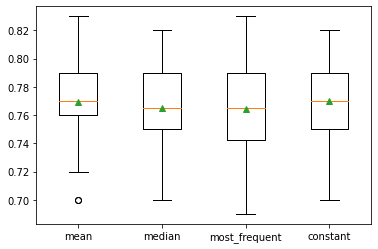

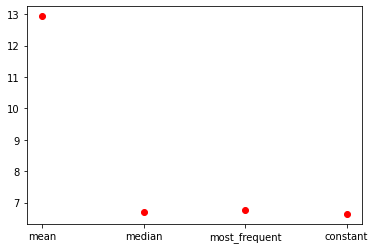

In [35]:
data = X_all.values
X, y = data[:, 0:-1], data[:, -1]
# Evaluamos las diferentes estrategias
results = []
finalresults = []
times = []
finaltimes = []
imputations = []
strategies = ['mean', 'median', 'most_frequent', 'constant']

for s in strategies:
    imputations.append(s)
    # Creamos la pipeline
    start = time.time()
    pipeline = Pipeline(steps=[('i', SimpleImputer(strategy=s)), ('m', RandomForestClassifier())])
    # Evaluamos el modelo
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    # Almacenamos los resultados y el tiempo de ejecución
    results.append(scores)
    end = time.time()
    final_time = end-start
    times.append(final_time)
    finalresults.append(scores)
    finaltimes.append(final_time)
    print('Modelo {}: Media - {:.3f} ; Desviacion - {:.3f} : Tiempo - {} '.format(s, np.mean(scores), np.std(scores), final_time))
# Dibujamos las bondad del modelo y el tiempo de ejecución para comparar
pyplot.boxplot(results, labels=strategies, showmeans=True)
pyplot.show()
pyplot.plot(strategies, times, 'ro')
pyplot.show()

#### Imputación con KNNImputer

Estrategia 1 vecinos: Media - 0.769 (0.027) Tiempo 8.058752059936523
Estrategia 3 vecinos: Media - 0.762 (0.029) Tiempo 11.61047649383545
Estrategia 5 vecinos: Media - 0.767 (0.027) Tiempo 9.868626117706299
Estrategia 7 vecinos: Media - 0.765 (0.032) Tiempo 8.209582090377808
Estrategia 9 vecinos: Media - 0.764 (0.027) Tiempo 8.20295238494873
Estrategia 15 vecinos: Media - 0.765 (0.030) Tiempo 8.20020318031311
Estrategia 18 vecinos: Media - 0.771 (0.027) Tiempo 8.15264081954956
Estrategia 21 vecinos: Media - 0.764 (0.027) Tiempo 9.101097106933594


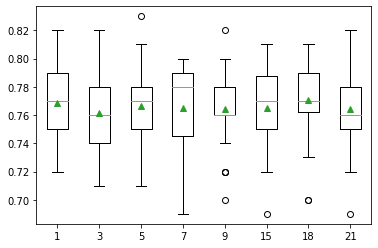

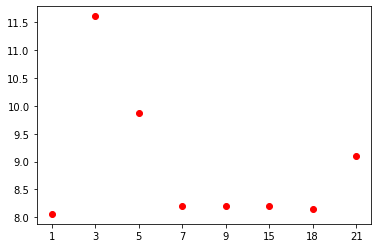

In [36]:
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, 0:-1], data[:, -1]
# Establecemos las estrategias de vecinos
results = []
times = []
strategies = [str(i) for i in [1,3,5,7,9,15,18,21]]

for s in strategies:
    name = 'knn ' + s
    imputations.append(name)
    start = time.time()
    # Creamos el modelo pipeline
    pipeline = Pipeline(steps=[('i', KNNImputer(n_neighbors=int(s))), ('m',
    RandomForestClassifier())])
    # Evaluamos el modelo
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    end = time.time()
    final_time = end-start
    # Almacenamos los resultados y el tiempo de ejecución
    results.append(scores)
    times.append(final_time)
    finalresults.append(scores)
    finaltimes.append(final_time)
    print('Estrategia {} vecinos: Media - {:.3f} ({:.3f}) Tiempo {}'.format(s, np.mean(scores), np.std(scores), final_time))
# Dibujamos los resultados y el tiempo de ejecución
pyplot.boxplot(results, labels=strategies, showmeans=True)
pyplot.show()
pyplot.plot(strategies, times, 'ro')
pyplot.show()

#### Imputación iterativa

Estrategia ascending - 0.765 (0.029 Tiempo 9.103230476379395)
Estrategia descending - 0.762 (0.031 Tiempo 9.005141735076904)
Estrategia roman - 0.767 (0.030 Tiempo 9.064579010009766)
Estrategia arabic - 0.764 (0.024 Tiempo 10.03261661529541)
Estrategia random - 0.769 (0.033 Tiempo 9.16508936882019)


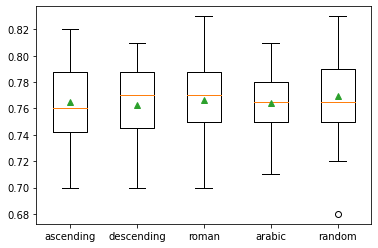

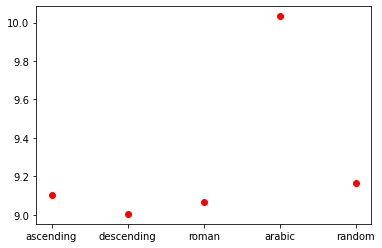

In [37]:
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, 0:-1], data[:, -1]
# Evaluamos las diferentes estrategias
results = []
times = []
strategies = ['ascending', 'descending', 'roman', 'arabic', 'random']
for s in strategies:
    name = 'iterative ' + s
    imputations.append(name)
    start = time.time()
    # Creamos el pipeline
    pipeline = Pipeline(steps=[('i', IterativeImputer(imputation_order=s)), ('m', RandomForestClassifier())])
    # Evaluamos el model
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    end = time.time()
    final_time = end-start
    # Almacenamos los resultados y el tiempo de ejecución
    results.append(scores)
    times.append(final_time)
    finalresults.append(scores)
    finaltimes.append(final_time)  
    print('Estrategia {} - {:.3f} ({:.3f} Tiempo {})'.format(s, np.mean(scores), np.std(scores), final_time))
# Dibujamos los datos de la comparativa
pyplot.boxplot(results, labels=strategies, showmeans=True)
pyplot.show()
pyplot.plot(strategies, times, 'ro')
pyplot.show()

Finalmente se pueden comparar todos los métodos analizados en los siguientes gráficos:

Modelo mean: Media - 0.769 ; Desviacion - 0.031 : Tiempo - 12.93356466293335 
Modelo median: Media - 0.765 ; Desviacion - 0.030 : Tiempo - 6.702366828918457 
Modelo most_frequent: Media - 0.764 ; Desviacion - 0.031 : Tiempo - 6.766037464141846 
Modelo constant: Media - 0.770 ; Desviacion - 0.029 : Tiempo - 6.637120485305786 
Modelo knn 1: Media - 0.769 ; Desviacion - 0.027 : Tiempo - 8.058752059936523 
Modelo knn 3: Media - 0.762 ; Desviacion - 0.029 : Tiempo - 11.61047649383545 
Modelo knn 5: Media - 0.767 ; Desviacion - 0.027 : Tiempo - 9.868626117706299 
Modelo knn 7: Media - 0.765 ; Desviacion - 0.032 : Tiempo - 8.209582090377808 
Modelo knn 9: Media - 0.764 ; Desviacion - 0.027 : Tiempo - 8.20295238494873 
Modelo knn 15: Media - 0.765 ; Desviacion - 0.030 : Tiempo - 8.20020318031311 
Modelo knn 18: Media - 0.771 ; Desviacion - 0.027 : Tiempo - 8.15264081954956 
Modelo knn 21: Media - 0.764 ; Desviacion - 0.027 : Tiempo - 9.101097106933594 
Modelo iterative ascending: Media - 0.765

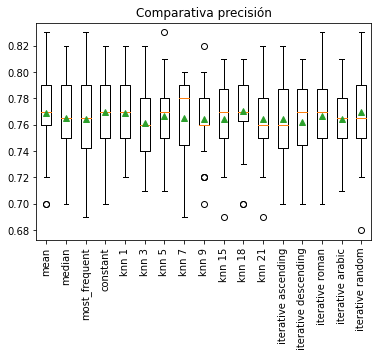

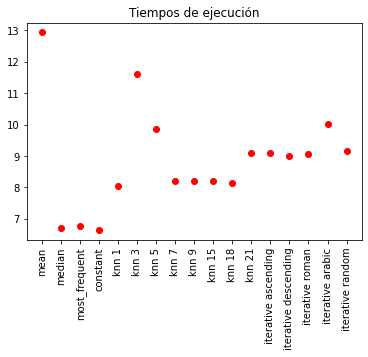

In [38]:
for i in range(len(imputations)):
    print('Modelo {}: Media - {:.3f} ; Desviacion - {:.3f} : Tiempo - {} '.format(imputations[i], np.mean(finalresults[i]), np.std(finalresults[i]), finaltimes[i]))

pyplot.boxplot(finalresults, labels=imputations, showmeans=True)
pyplot.title('Comparativa precisión')
pyplot.xticks(rotation=90)
pyplot.show()
pyplot.plot(imputations, finaltimes, 'ro')
pyplot.title('Tiempos de ejecución')
pyplot.xticks(rotation=90)
pyplot.show()

En vista del gráfico que compara los distintos métodos de imputación, se puede concluir que en nuestro caso, el mejor método para imputar es el de KNN Imputer con k=3 vecinos. Por lo, tanto será ese método el que se usará de manera predeterminada para imputar los Nan.

Se aplica el método de imputación más indicado y se separa en training set y test set el dataset.

In [39]:
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, :-1], data[:, -1]

# Definimos el imputer
imputer = KNNImputer(n_neighbors = 3)
# Entrenamos sobre el dataset
imputer.fit(X)
# Transformamos el dataset
X = imputer.transform(X)

# Se separa el trainig set y el test set 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

# Se escalan los resultados
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
  
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [40]:
X_df=pd.DataFrame(X)
X_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
0,2.0,1.0,1.0,4.0,2.0,17.0,0.0,2.0,2.000000,0.0,4.0,4.0,1.0,1.000000,1.000000,10.0,1.0,328.0,48.0,1000.0,1406.91,0.0,53300.0,0.0,5.0,1.0,1.0,2.0,71610.0,6510.0,13020.0,52080.0,2004.0
1,1.0,1.0,1.0,4.0,6.0,15.0,2.0,3.0,1.333333,1.0,4.0,5.0,5.0,0.666667,0.000000,8.0,12.0,228.0,42.0,2000.0,1197.22,5000000.0,0.0,0.0,8.0,1.0,0.0,0.0,5070.0,780.0,780.0,3510.0,2007.0
2,2.0,0.0,0.0,6.0,11.0,2.0,3.0,0.0,1.000000,1.0,4.0,1.0,1.0,0.000000,0.000000,4.0,30.0,134.0,29.0,2000.0,1413.14,5000000.0,35100.0,0.0,7.0,3.0,2.0,3.0,34650.0,7700.0,3850.0,23100.0,2007.0
3,0.0,1.0,0.0,6.0,1.0,2.0,4.0,2.0,0.000000,0.0,4.0,2.0,0.0,1.000000,0.000000,3.0,34.0,256.0,41.0,2000.0,1415.74,6000000.0,48900.0,-62400.0,5.0,1.0,1.0,2.0,63400.0,6340.0,6340.0,50720.0,2014.0
4,0.0,2.0,1.0,0.0,11.0,2.0,4.0,3.0,1.666667,1.0,2.0,1.0,0.0,0.000000,0.000000,0.0,31.0,228.0,44.0,1000.0,1583.91,6000000.0,66000.0,-46000.0,20.0,1.0,0.0,1.0,6500.0,1300.0,650.0,4550.0,2009.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2.0,2.0,0.0,5.0,2.0,13.0,4.0,2.0,0.000000,1.0,1.0,0.0,4.0,1.000000,0.333333,6.0,6.0,3.0,38.0,1000.0,1310.80,0.0,0.0,0.0,20.0,1.0,0.0,1.0,87200.0,17440.0,8720.0,61040.0,2006.0
996,0.0,0.0,0.0,6.0,9.0,17.0,5.0,2.0,1.000000,0.0,1.0,4.0,3.0,1.000000,0.333333,13.0,28.0,285.0,41.0,1000.0,1436.79,0.0,70900.0,0.0,23.0,1.0,2.0,3.0,108480.0,18080.0,18080.0,72320.0,2015.0
997,2.0,1.0,0.0,5.0,1.0,3.0,2.0,0.0,2.000000,1.0,4.0,0.0,0.0,0.333333,1.000000,11.0,19.0,130.0,34.0,500.0,1383.49,3000000.0,35100.0,0.0,4.0,3.0,2.0,3.0,67500.0,7500.0,7500.0,52500.0,1996.0
998,0.0,2.0,1.0,0.0,5.0,0.0,5.0,2.0,1.000000,0.0,3.0,1.0,0.0,0.666667,1.000000,1.0,5.0,458.0,62.0,2000.0,1356.92,5000000.0,0.0,0.0,2.0,1.0,0.0,1.0,46980.0,5220.0,5220.0,36540.0,1998.0


###Matriz de correlación

Vamos a presentar la matriz de correlación para analizar un poco más en detalle los datos.

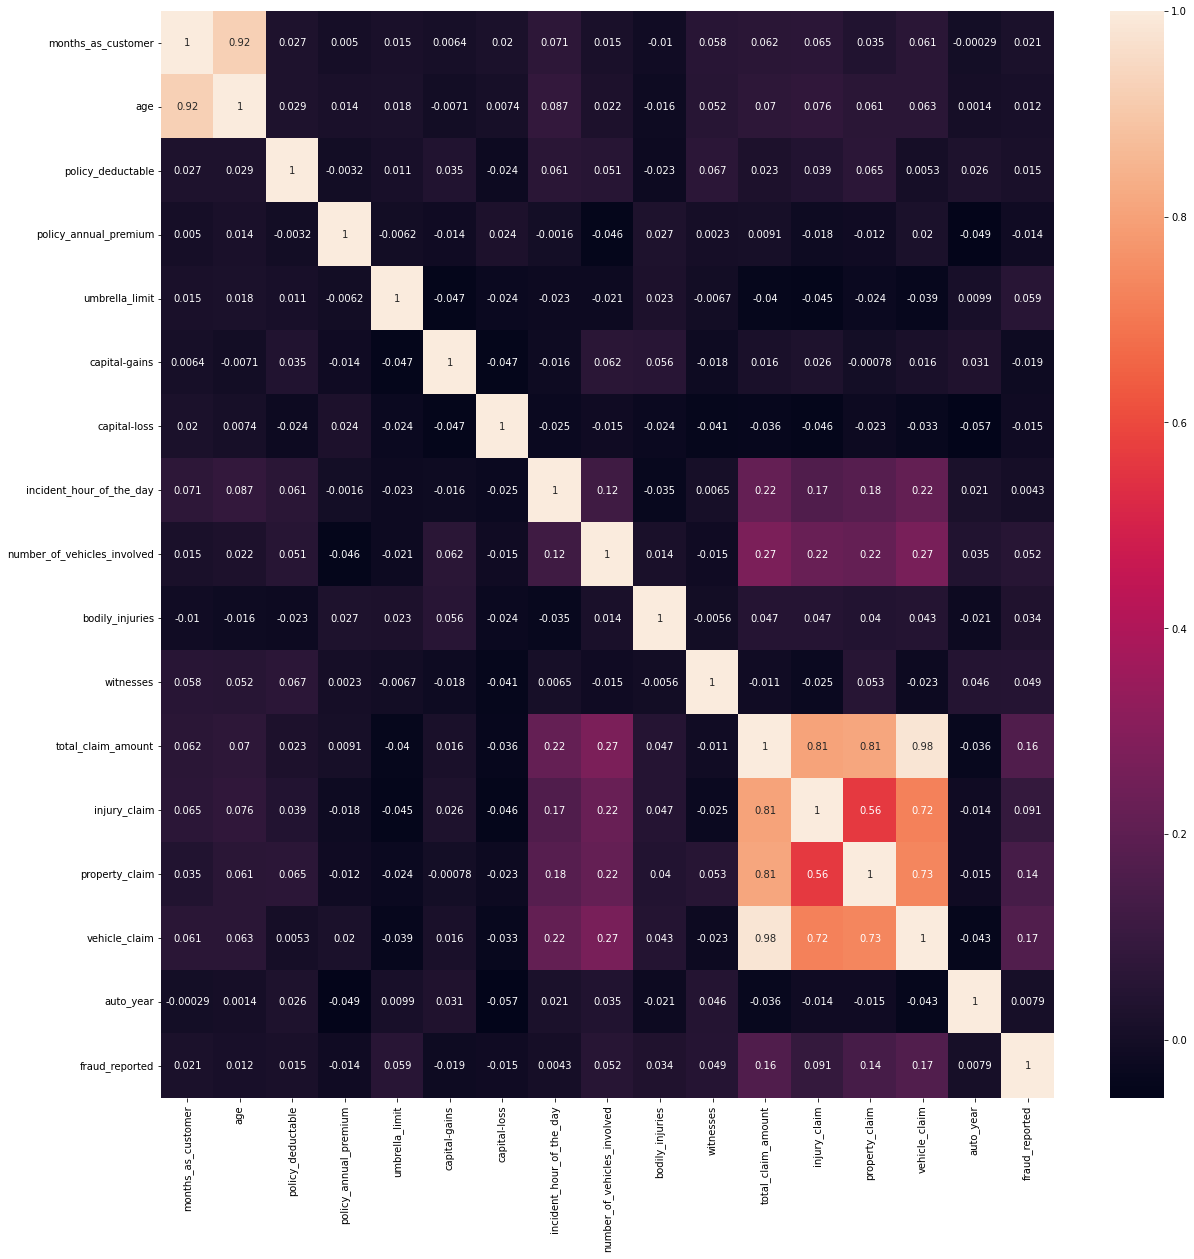

In [41]:
correlation = X_numerical.corr()
f, ax = pyplot.subplots(figsize=(20,20))
sns.heatmap(correlation, annot=True)



Se puede observar que en la matriz de correlación existen parejas de columnas que están altamente correlacionadas. Concretamente, son* month_as_a_customer* con *age* y *total_claim* con *vehicle_claim*. Mediante esta observación, podríamos quedarnos solamente con la columna de cada pareja que esté más correlacionada con fraud report.

A continuación, se dividen las variables independientes y la etiqueta

In [42]:
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, :-1], data[:, -1]

# Definimos el imputer
imputer = KNNImputer(n_neighbors = 3)
# Entrenamos sobre el dataset
imputer.fit(X)
# Transformamos el dataset
X = imputer.transform(X)

X_new=np.delete(X,[18,28], axis=1)
# Se separa el trainig set y el test set 
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.33, random_state=1)

# Se escalan los resultados
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
  
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [43]:
#Apliquem un RandomForest
model = RandomForestClassifier()
# Entrenem el model
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
#mirem la precisió
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_test, y_test, scoring='accuracy', cv=cv, n_jobs=-1)
print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')


Precision: 0.754 (0.052)


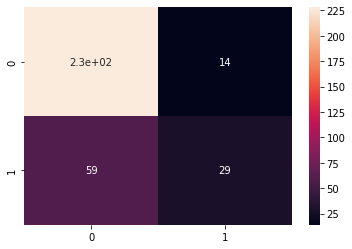

In [44]:
#mirem la confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

##Extracción de características (RFE,PCA y SVD).

En esta fase veremos brevemente unos métodos de extracción de características.

### RFE para clasificación

In [45]:
#RFE 

import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Creamos la pipeline
rfe = RFE(estimator=DecisionTreeClassifier(), n_features_to_select=5)
model = DecisionTreeClassifier()
pipeline = Pipeline(steps=[('s',rfe),('m',model)])
# Evaluamos el modelo
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
# Presentamos la precision del modelo
print('Precision:{:.3f} ({:.3f})'.format(np.mean(n_scores), np.std(n_scores)))

Precision:0.789 (0.048)


Optimal number of features : 4


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:103: FutureWarning: The `grid_scores_` attribute is deprecated in version 1.0 in favor of `cv_results_` and will be removed in version 1.2.
  warnings.warn(msg, category=FutureWarning)


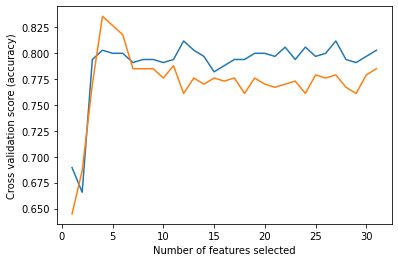

array([27, 17, 26, 25,  9,  1,  5, 19, 28,  1, 18,  8,  3, 13, 22,  4, 12,
        2, 15,  7, 14, 16, 23, 10, 11, 20, 24,  6,  1, 21,  1])

In [46]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification


# Create the RFE object and compute a cross-validated score.

# The "accuracy" scoring shows the proportion of correct classifications

min_features_to_select = 1  # Minimum number of features to consider
rfecv = RFECV(
    estimator=DecisionTreeClassifier(),
    step=1,
    cv=StratifiedKFold(2),
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
)
rfecv.fit(X_train, y_train)

print("Optimal number of features : %d" % rfecv.n_features_)

# Plot number of features VS. cross-validation scores
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (accuracy)")
plt.plot(
    range(min_features_to_select, len(rfecv.grid_scores_) + min_features_to_select),
    rfecv.grid_scores_,
)
plt.show()
rfecv.ranking_

In [47]:
X_train.shape
X_train2=X_train[[5,9,12,27,28,30]]
X_train2
X_test2=X_test[[5,9,12,27,28,30]]

### PCA y SVD

In [48]:
#PCA
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression


# Definimos la pipeline
steps = [('pca', PCA(n_components=10)), ('m', LogisticRegression())]
model = Pipeline(steps=steps)
# Evaluamos el modelo
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
# Sacamos la precision
#Amb 10 components
print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')

Precision: 0.764 (0.013)


In [49]:
#Variància acumulada per cada n de components

# Definimos la pipeline
pca = PCA(svd_solver='full')
# Aplicamos el modelo
pca.fit(X_train)
# Sacamos la información del modelo
acc = 0
for i, (val, var) in enumerate(zip(pca.singular_values_, pca.explained_variance_ratio_)):
    acc += var * 100
    print(f'Componente: {i} - Singular value :{val:.4f} - Varianza explicada: {var*100:.4f} % - Acumulada: {acc:.4f} %')

Componente: 0 - Singular value :13.9227 - Varianza explicada: 8.3013 % - Acumulada: 8.3013 %
Componente: 1 - Singular value :13.0984 - Varianza explicada: 7.3474 % - Acumulada: 15.6487 %
Componente: 2 - Singular value :11.8879 - Varianza explicada: 6.0522 % - Acumulada: 21.7008 %
Componente: 3 - Singular value :11.4411 - Varianza explicada: 5.6058 % - Acumulada: 27.3066 %
Componente: 4 - Singular value :11.0619 - Varianza explicada: 5.2403 % - Acumulada: 32.5470 %
Componente: 5 - Singular value :10.7077 - Varianza explicada: 4.9101 % - Acumulada: 37.4571 %
Componente: 6 - Singular value :10.6322 - Varianza explicada: 4.8411 % - Acumulada: 42.2982 %
Componente: 7 - Singular value :10.3556 - Varianza explicada: 4.5925 % - Acumulada: 46.8907 %
Componente: 8 - Singular value :10.1969 - Varianza explicada: 4.4528 % - Acumulada: 51.3435 %
Componente: 9 - Singular value :9.7862 - Varianza explicada: 4.1013 % - Acumulada: 55.4448 %
Componente: 10 - Singular value :9.3798 - Varianza explicada: 

In [50]:
#SVD

from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

# Definimos el pipeline
steps = [('svd', TruncatedSVD(n_components=10)), ('m', LogisticRegression())]
model = Pipeline(steps=steps)
# Evaluamos el modelo
#Sacamos precisión
#Amb 10 components
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')

Precision: 0.761 (0.017)


In [51]:
# Definimos la pipeline
svd = TruncatedSVD(n_components=30)
# Aplicamos el modelo
svd.fit(X_train)
# Sacamos la información del modelo
acc = 0
for i, (val, var) in enumerate(zip(svd.singular_values_, svd.explained_variance_ratio_)):
    acc += var * 100
    print(f'Componente: {i} - Singular value :{val:.4f} - Varianza explicada: {var*100:.4f} % - Acumulada: {acc:.4f} %')

Componente: 0 - Singular value :68.4003 - Varianza explicada: 3.2088 % - Acumulada: 3.2088 %
Componente: 1 - Singular value :13.8920 - Varianza explicada: 8.2639 % - Acumulada: 11.4728 %
Componente: 2 - Singular value :13.0421 - Varianza explicada: 7.2832 % - Acumulada: 18.7560 %
Componente: 3 - Singular value :11.8251 - Varianza explicada: 5.9877 % - Acumulada: 24.7437 %
Componente: 4 - Singular value :11.3658 - Varianza explicada: 5.5315 % - Acumulada: 30.2752 %
Componente: 5 - Singular value :11.0599 - Varianza explicada: 5.2385 % - Acumulada: 35.5137 %
Componente: 6 - Singular value :10.6323 - Varianza explicada: 4.8412 % - Acumulada: 40.3548 %
Componente: 7 - Singular value :10.4393 - Varianza explicada: 4.6666 % - Acumulada: 45.0214 %
Componente: 8 - Singular value :10.2162 - Varianza explicada: 4.4696 % - Acumulada: 49.4909 %
Componente: 9 - Singular value :9.8827 - Varianza explicada: 4.1791 % - Acumulada: 53.6700 %
Componente: 10 - Singular value :9.7575 - Varianza explicada: 

##Selección de variables 

En este apartado del modelo, seleccionamos las columnas de X_train que luego utilizaremos para mejorar la precisión. Esta selección se hará en función del método que nos de un mejor resultado.

### Categóricas

#### Estadístico chi-2

Donde se puede observar como las variables con una mayor dependencia a la etiqueta son la 9 y la 13.

Variable 0: 0.3321144476973485
Variable 1: 0.20702297672667422
Variable 2: 0.6208117433240197
Variable 3: 0.03575499587074013
Variable 4: 0.06533376011047054
Variable 5: 0.17250996989021683
Variable 6: 0.11589452746863285
Variable 7: 0.97755646508963
Variable 8: 8.563358516881355e-05
Variable 9: 28.79848574045356
Variable 10: 0.7242086336167493
Variable 11: 0.24694494343134984
Variable 12: 0.5195199395013256
Variable 13: 3.6668976962806963
Variable 14: 0.39797778045414056
Variable 15: 0.10714277412253786
Variable 16: 0.0015809563261654233


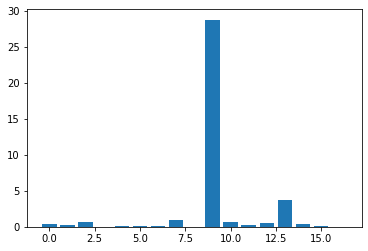

In [52]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from matplotlib import pyplot


# Seleccionamos las variables
def select_features(X_train, y_train, X_test):
    fs = SelectKBest(score_func=chi2, k='all')
    fs.fit(X_train, y_train)
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs


def knn_imputation(X, n):
    # Dividimos las variables independientes y la etiqueta
    # data = df.values
    # Definimos el imputer
    imputer = KNNImputer(n_neighbors = int(n))
    # Entrenamos sobre el dataset
    imputer.fit(X)
    # Transformamos el dataset
    Xtrans = imputer.transform(X)
    return Xtrans

# Realizamos el cálculo solo en las variables categóricas
X_cat_n = knn_imputation(X_cat, 3)

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat_n, y, test_size=0.33, random_state=1)
scaler = MinMaxScaler()
scaler.fit(X_train_cat)
X_train_cat = scaler.transform(X_train_cat)
X_test_cat = scaler.transform(X_test_cat)

# Seleccionamos las variables
X_train_fs, X_test_fs, fs = select_features(X_train_cat, y_train_cat, X_test_cat)
# Puntuamos las variables para su selección
for i in range(len(fs.scores_)):
    print('Variable {}: {}'.format(i, fs.scores_[i]))
# Dibujamos los scores
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()

#### Estadístico de información mutua


Devuelve el grado de dependencia entre las variables y la variable etiqueta. En este caso las más dependientes han sido la 5 y la 9.

Variable 0: 0.0
Variable 1: 0.0
Variable 2: 0.0
Variable 3: 0.0
Variable 4: 0.012680666270209251
Variable 5: 0.0633388767272447
Variable 6: 0.0
Variable 7: 0.0
Variable 8: 0.01102944061202149
Variable 9: 0.14086986994566786
Variable 10: 0.011629690675392323
Variable 11: 0.011343653870157011
Variable 12: 0.02656423804766206
Variable 13: 0.0
Variable 14: 0.0
Variable 15: 0.00014862047581365445
Variable 16: 0.02074460032176928


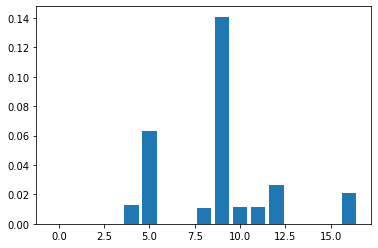

In [53]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

# Seleccionamos las variables
def select_features(X_train, y_train, X_test):
    fs = SelectKBest(score_func=mutual_info_classif, k='all')
    fs.fit(X_train, y_train)
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs

# Seleccionamos las variables
X_train_fs, X_test_fs, fs = select_features(X_train_cat, y_train_cat, X_test_cat)
# Puntuamos las variables para su selección
for i in range(len(fs.scores_)):
    print('Variable {}: {}'.format(i, fs.scores_[i]))
# Dibujamos los scores
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()

Observando los resultados de estas dos técnicas se han determinado aquellas variables menos dependientes de la variable de salida. A continuación se ha analizado el efecto que tendría en la predicción el borrado de estas variables:

In [54]:
from xgboost import XGBClassifier

delete = [0, 3, 4, 6, 8, 12, 14, [0, 3, 8, 12], [8, 12, 14], [0, 3, 6, 8, 12, 14], [0, 3, 4, 6, 8, 12, 14]]
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, :-1], data[:, -1]

# Definimos el imputer
imputer = KNNImputer(n_neighbors = 3)
# Entrenamos sobre el dataset
imputer.fit(X)
# Transformamos el dataset
X = imputer.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

# Se escalan los resultados
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
    
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

  
model = XGBClassifier()
  
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
  
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_test, y_test, scoring='accuracy', cv=cv, n_jobs=-1)
print(f'Precision inicial: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')

for i in delete:
    X_new=np.delete(X,[i], axis=1)
    # Se separa el trainig set y el test set 
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.33, random_state=1)

    # Se escalan los resultados
    scaler = MinMaxScaler()
    scaler.fit(X_train_new)
    X_train_new = scaler.transform(X_train_new)
    X_test_new = scaler.transform(X_test_new)
      
    X_train_new = pd.DataFrame(X_train_new)
    X_test_new = pd.DataFrame(X_test_new)

    model = XGBClassifier()
    
    model.fit(X_train_new, y_train_new)
    y_pred_new=model.predict(X_test_new)
    
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    n_scores = cross_val_score(model, X_test_new, y_test_new, scoring='accuracy', cv=cv, n_jobs=-1)
    print(f'Precision sin la(s) variable(s) {i}: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')


Precision inicial: 0.826 (0.046)
Precision sin la(s) variable(s) 0: 0.829 (0.051)
Precision sin la(s) variable(s) 3: 0.824 (0.050)
Precision sin la(s) variable(s) 4: 0.822 (0.052)
Precision sin la(s) variable(s) 6: 0.823 (0.050)
Precision sin la(s) variable(s) 8: 0.825 (0.045)
Precision sin la(s) variable(s) 12: 0.831 (0.043)
Precision sin la(s) variable(s) 14: 0.830 (0.044)
Precision sin la(s) variable(s) [0, 3, 8, 12]: 0.827 (0.046)
Precision sin la(s) variable(s) [8, 12, 14]: 0.821 (0.047)
Precision sin la(s) variable(s) [0, 3, 6, 8, 12, 14]: 0.823 (0.049)
Precision sin la(s) variable(s) [0, 3, 4, 6, 8, 12, 14]: 0.820 (0.048)


Así pues, se puede observar como al quitar las variables con menos dependencia la precisión mejora en algunos casos, así que se podrían eliminar.
En este caso, **la mejor precisión se obtiene al eliminar la columna 12**, con una precisión del 83.1% y un varianza del 0.043.

### Numéricas

#### Coeficiente de correlación ANOVA

Cuanto mayor sea el coeficiente mayor será la correlación. Columnas más correladas: 28, 30 y 31.

Feature 0: 0.12119934155439868
Feature 1: 0.2689367622521598
Feature 2: 1.0530572175352326
Feature 3: 0.23844259225548373
Feature 4: 1.4433731513111807
Feature 5: 1.365063308269211
Feature 6: 0.013035200371580308
Feature 7: 0.2027182870316442
Feature 8: 3.2342809962243493
Feature 9: 1.0504015550429366
Feature 10: 2.7657209855895073
Feature 11: 17.763821597907775
Feature 12: 5.247702793524959
Feature 13: 13.323621635316904
Feature 14: 18.958834997558128
Feature 15: 0.09254926620589841


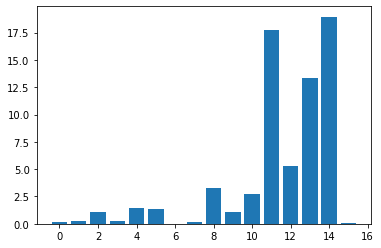

In [55]:
# Funcion para seleccionar las variables
def select_features(X_train, y_train, X_test):
    # Configuramos el selector a todas las variables
    fs = SelectKBest(score_func=f_classif, k='all')
    # Entrenamos el selector sobre el conjunto de train
    fs.fit(X_train, y_train)
    # Transformamos los datos de entrenamiento
    X_train_fs = fs.transform(X_train)
    # Transformamos los datos de test
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs

def scaler_function(X_train,X_test):
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = pd.DataFrame(X_train)
    X_test= pd.DataFrame(X_test)
    return X_train,X_test

# Realizamos el cálculo solo en las variables numericas
X_num = X_numerical.to_numpy()[:, :-1]
y = X_all.to_numpy()[:, -1]

# Dividimos train y test
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y, test_size=0.33, random_state=1)

# Escalamos los datos
X_train_num, X_test_num = scaler_function(X_train_num, X_test_num)

# Seleccionamos las variables
X_train_fs, X_test_fs, fs = select_features(X_train_num, y_train_num, X_test_num)

# Imprimimos la puntuacion de las variables
for i in range(len(fs.scores_)):
    print('Feature {}: {}'.format(i, fs.scores_[i]))
# Dibujamos la puntuación
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()


####Precisión al eliminar variables

Vamos a eliminar las columnas con valores más bajos de correlación según el coeficiente de correlación Anova. Se han elegido las 3 columnas con valores más bajos, estas columnas son la 17, 23 y 32. Se ha mirado la precisión obtenida al eliminar estas columnas únicamente, y una combinación de las mismas. Finalmente, se ha obtenido un valor de precisión más alto al eliminar las 3 columnas juntas, siendo esta precisión de 83.3%, con una varianza de 0,043. En el caso de eliminar la columna 17 y la 23 por separado, las precisiones obtenidas difieren en una décima, es decir, una precisión de 83.2, pero con una varianza mayor, y en el caso de eliminar las 6 columnas con valores más bajos juntas, se obtiene una precisión también del 83.3%, pero la varianza también es mayor.

**Por lo tanto, finalmente se escogería eliminar las columnas 17, 23 y 32 conjuntamente.**

In [56]:
indextodelete = [17,23,32, [17,23], [17,32], [23,32], [17,23,32], [17,18,20,23,24,32]]
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, :-1], data[:, -1]

# Definimos el imputer
imputer = KNNImputer(n_neighbors = 3)
# Entrenamos sobre el dataset
imputer.fit(X)
# Transformamos el dataset
X = imputer.transform(X)

X_num = X_numerical.to_numpy()[:, :-1]
y = X_all.to_numpy()[:, -1]


for i in indextodelete:
    X_new=np.delete(X,[i], axis=1)
    # Se separa el trainig set y el test set 
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.33, random_state=1)

    # Se escalan los resultados
    scaler = MinMaxScaler()
    scaler.fit(X_train_new)
    X_train_new = scaler.transform(X_train_new)
    X_test_new = scaler.transform(X_test_new)
    
    X_train_new = pd.DataFrame(X_train_new)
    X_test_new = pd.DataFrame(X_test_new)

    model = XGBClassifier()
  
    model.fit(X_train_new, y_train_new)
    y_pred_new=model.predict(X_test_new)
  
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    n_scores = cross_val_score(model, X_test_new, y_test_new, scoring='accuracy', cv=cv, n_jobs=-1)
    print(f'Precision sin la(s) variable(s) {i}: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')

Precision sin la(s) variable(s) 17: 0.832 (0.049)
Precision sin la(s) variable(s) 23: 0.832 (0.047)
Precision sin la(s) variable(s) 32: 0.823 (0.048)
Precision sin la(s) variable(s) [17, 23]: 0.830 (0.043)
Precision sin la(s) variable(s) [17, 32]: 0.832 (0.044)
Precision sin la(s) variable(s) [23, 32]: 0.828 (0.044)
Precision sin la(s) variable(s) [17, 23, 32]: 0.833 (0.043)
Precision sin la(s) variable(s) [17, 18, 20, 23, 24, 32]: 0.833 (0.046)


#### Con función de selección por información mutua 

Se mide la dependencia entre las variables. Cuanto mayor sea el valor, mayor será la dependencia.
Columnas con valores más altos: 22 y 30.

Feature 0: 0.012564067525021372
Feature 1: 0.013187784319367069
Feature 2: 0.034141860611491825
Feature 3: 0.01818779097274259
Feature 4: 0.03416555920848863
Feature 5: 0.0
Feature 6: 0.020170185057301282
Feature 7: 0.04146959844805931
Feature 8: 0.0294582362492668
Feature 9: 0.014726607291077443
Feature 10: 0.020967999208393984
Feature 11: 0.008965911047835284
Feature 12: 0.05095862007260887
Feature 13: 0.04066984355845982
Feature 14: 0.008799343738135512
Feature 15: 0.009769613913895192


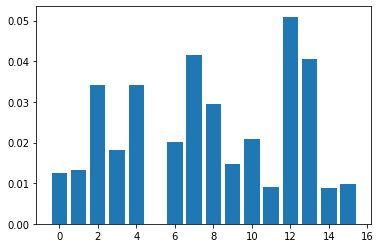

In [57]:
# Funcion para seleccionar las variables
def select_features(X_train, y_train, X_test):
    # Configuramos el selector a todas las variables
    fs = SelectKBest(score_func=mutual_info_regression, k='all')
    # Entrenamos el selector sobre el conjunto de train
    fs.fit(X_train, y_train)
    # Transformamos los datos de entrenamiento
    X_train_fs = fs.transform(X_train)
    # Transformamos los datos de test
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs

# Realizamos el cálculo solo en las variables numericas
X_num = X_numerical.to_numpy()[:, :-1]
y = X_all.to_numpy()[:, -1]

# Dividimos train y test
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y, test_size=0.33, random_state=1)

# Escalamos los datos
X_train_num, X_test_num = scaler_function(X_train_num, X_test_num)

# Seleccionamos las variables
X_train_fs, X_test_fs, fs = select_features(X_train_num, y_train_num, X_test_num)

# Imprimimos la puntuacion de las variables
for i in range(len(fs.scores_)):
    print('Feature {}: {}'.format(i, fs.scores_[i]))
# Dibujamos la puntuación
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()

####Precisión al eliminar variables

Vamos a eliminar las columnas con valores más bajos de correlación según la función de selección por información mutua. Se han elegido las 3 columnas con valores más bajos, estas columnas son la 21, 23 y 26. Se ha mirado la precisión obtenida al eliminar estas columnas únicamente, y una combinación de las mismas. También se ha evaluado la precisión al eliminar las 6 columnas con valores más bajos. Finalmente, se ha obtenido un valor de precisión más alto al eliminar las 6 columnas con valores más bajos, siendo esta precisión de 84.0%, con una varianza de 0.055. Seguidamente, en el caso de eliminar las columnas 21, 23 y 26, la precisión obtenida es de 83.7%, muy cercana a 84%, pero con una varianza menor, 0.048.

**Por lo tanto, finalmente la mejor opción sería eliminar las columnas 21, 23 y 26, que inicialmente son las columnas que dan un valor más bajo, 0.0.**

In [58]:
indextodelete = [21, 23, 26, [21,23], [21,26], [23,26], [21,23,26], [21,23,26,27,28,32]]
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, :-1], data[:, -1]

# Definimos el imputer
imputer = KNNImputer(n_neighbors = 3)
# Entrenamos sobre el dataset
imputer.fit(X)
# Transformamos el dataset
X = imputer.transform(X)

X_num = X_numerical.to_numpy()[:, :-1]
y = X_all.to_numpy()[:, -1]


for i in indextodelete:
    X_new=np.delete(X,[i], axis=1)
    # Se separa el trainig set y el test set 
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.33, random_state=1)

    # Se escalan los resultados
    scaler = MinMaxScaler()
    scaler.fit(X_train_new)
    X_train_new = scaler.transform(X_train_new)
    X_test_new = scaler.transform(X_test_new)
    
    X_train_new = pd.DataFrame(X_train_new)
    X_test_new = pd.DataFrame(X_test_new)

    model = XGBClassifier()
  
    model.fit(X_train_new, y_train_new)
    y_pred_new=model.predict(X_test_new)
  
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    n_scores = cross_val_score(model, X_test_new, y_test_new, scoring='accuracy', cv=cv, n_jobs=-1)
    print(f'Precision sin la(s) variable(s) {i}: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')

Precision sin la(s) variable(s) 21: 0.826 (0.043)
Precision sin la(s) variable(s) 23: 0.832 (0.047)
Precision sin la(s) variable(s) 26: 0.829 (0.045)
Precision sin la(s) variable(s) [21, 23]: 0.832 (0.049)
Precision sin la(s) variable(s) [21, 26]: 0.826 (0.048)
Precision sin la(s) variable(s) [23, 26]: 0.836 (0.049)
Precision sin la(s) variable(s) [21, 23, 26]: 0.837 (0.048)
Precision sin la(s) variable(s) [21, 23, 26, 27, 28, 32]: 0.840 (0.055)


##Importancia de variables

En esta parte se estudia la importancia de cada columna por separado dado un modelo específico. Esta será uno de los pilares del proyecto ya que de aquí escogeremos las columnas que utilizaremos más adelante y también el modelo. Estudiaremos las columnas más relevantes para los modelos de regresión logística, cart classifier, random forest classifier, xgb y método de permutación con repetición.

###Datos y funciones 

Primero creamos un conjunto útil de funciones que usaremos en esta parte y cargamos los datos

In [59]:
#Función que escala 
def scaler_function(X_train,X_test):
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = pd.DataFrame(X_train)
    X_test= pd.DataFrame(X_test)
    return X_train,X_test

#Función que devuelve lista con las columnas menos importantes
def top_columns(top_number,scores,indexes,importance):
    #Lista ordenada de menor a mayor importancia
    sorted_scores=sorted(scores)

    importance_list= list(importance)
    #sorted_dictionary with key = order , value = importance number
    dictionary_scores= dict(zip(indexes,sorted_scores))
    new_importance_list= [abs(importance_list[i]) for i in range(len(importance_list))]

    top_columns_index=[]
    print(dictionary_scores)
    for key,value in dictionary_scores.items():
        if key< top_number: 
            previous_index=new_importance_list.index(value)
            print(f" Variable: { previous_index} Score: {importance_list[previous_index]} ")
            top_columns_index.append(previous_index)
        if new_importance_list[previous_index]==0:
            new_importance_list[previous_index]=0.00001

    print(top_columns_index)
    return top_columns_index

#Función que itera sobre un modelo y un conjunto de columnas especificas a quitar y un scoring_method 
def model_iterator(top_columns_index,model_given,scoring_method):
    #Iteramos quitando todas las columnas y viendo que pasa con cada eliminación
    top_columns_iterator=[]
    results_model=[]

    for i in top_columns_index:
        top_columns_iterator.append(i)
        print(f"Columnas eliminadas : {top_columns_iterator}")
        X_new=np.delete(X,top_columns_iterator, axis=1)
        # Se separa el trainig set y el test set 
        X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.33, random_state=1)
        # Se escalan los resultados
        X_train,X_test=scaler_function(X_train,X_test)
        #Apliquem un model
        model = model_given
        # Entrenem el model
        model.fit(X_train, y_train)
        y_pred=model.predict(X_test)
        #mirem la precisió
        cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
        n_scores = cross_val_score(model, X_test, y_test, scoring=scoring_method, cv=cv, n_jobs=-1)
        print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')
        results_model.append(n_scores)
        #Restauramos columnas
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

    # Se escalan los resultados
    X_train,X_test=scaler_function(X_train,X_test)
    return results_model


def ploting(results_model):
    # Dibujamos las bondad del modelo y el tiempo de ejecución para comparar
    labels_model=[i+1 for i in range (len(results_model))]
    pyplot.boxplot(results_model, labels=labels_model, showmeans=True)
    pyplot.show()

def ploting_all_scorings(scoring_list,top_columns_index):
    for i in range(len(scoring_list)):
        print(f"Scoring: {scoring_list[i]} \n")
        results_model=model_iterator(top_columns_index,model,scoring_list[i])
        ploting(results_model)

In [60]:
# Dividimos las variables independientes y la etiqueta
data = X_all.values
X, y = data[:, :-1], data[:, -1]
# Definimos el imputer
imputer = KNNImputer(n_neighbors = 3)
# Entrenamos sobre el dataset
imputer.fit(X)
# Transformamos el dataset
X = imputer.transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
#Se escalan los datos
X_train,X_test=scaler_function(X_train,X_test)

scoring_list=['accuracy','neg_log_loss','roc_auc']


Vamos a obtener las columnas más importantes para los métodos de regresión logística, decisiontreeclassifier, randomforest,xgbclassifier y permutación para clasificación. Una vez obtenidas las columnas,identificaremos las menos importantes y graficaremos la precisión en función de las columnas eliminadas.

###Regresión logística

Variable: 0, Score: 0.35196
Variable: 1, Score: -0.16320
Variable: 2, Score: 0.11781
Variable: 3, Score: -0.15208
Variable: 4, Score: -0.03181
Variable: 5, Score: -0.40978
Variable: 6, Score: 0.13252
Variable: 7, Score: 0.00252
Variable: 8, Score: -0.03704
Variable: 9, Score: -3.39027
Variable: 10, Score: 0.01226
Variable: 11, Score: -0.06952
Variable: 12, Score: -0.42051
Variable: 13, Score: 0.47144
Variable: 14, Score: -0.04479
Variable: 15, Score: -0.15796
Variable: 16, Score: -0.09604
Variable: 17, Score: 0.11497
Variable: 18, Score: -0.42277
Variable: 19, Score: 0.15496
Variable: 20, Score: -0.16186
Variable: 21, Score: 0.66432
Variable: 22, Score: -0.32555
Variable: 23, Score: -0.07303
Variable: 24, Score: -0.14160
Variable: 25, Score: 0.14896
Variable: 26, Score: 0.22348
Variable: 27, Score: 0.25888
Variable: 28, Score: 0.32327
Variable: 29, Score: -0.46361
Variable: 30, Score: 0.18018
Variable: 31, Score: 0.53769
Variable: 32, Score: -0.01690


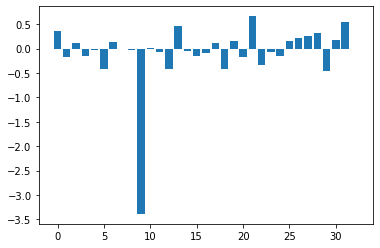

In [61]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot

scores=[]
indexes=[]
# Definimos el modelo
model = LogisticRegression()
# Entrenamos el modelo
model.fit(X_train, y_train)
# Vemos la importancia de cada variable
importance = model.coef_[0]

# Presentamos la importancia de cada variable
for i,v in enumerate(importance):
    print('Variable: {}, Score: {:.5f}'.format(i,v))
    scores.append(abs(v))
    indexes.append(i)

# Dibujamos la importancia para comparar visualmente
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [62]:
#Lista ordenada de menor a mayor importancia de columnas
top_number=28
top_columns_index=top_columns(top_number,scores,indexes,importance)

{0: 0.002518707155468159, 1: 0.012262553358168891, 2: 0.016895758577550817, 3: 0.03181336923870678, 4: 0.037041715738410926, 5: 0.04479449673439296, 6: 0.06952246151324727, 7: 0.07303392383462502, 8: 0.09604386588900035, 9: 0.11497287483666847, 10: 0.11780587911708969, 11: 0.13252065973168695, 12: 0.14160163785336502, 13: 0.1489612704795985, 14: 0.15207901460101605, 15: 0.1549580616108053, 16: 0.15795723997065672, 17: 0.16186292700042731, 18: 0.16319592723578932, 19: 0.1801790452495477, 20: 0.2234768521785504, 21: 0.25887943342618563, 22: 0.32326785471386565, 23: 0.3255543568589476, 24: 0.3519576913411328, 25: 0.4097815590575757, 26: 0.420507744807296, 27: 0.4227748790981689, 28: 0.46360881268392484, 29: 0.4714405260962622, 30: 0.5376921831332215, 31: 0.6643236244937687, 32: 3.3902691338033395}
 Variable: 7 Score: 0.002518707155468159 
 Variable: 10 Score: 0.012262553358168891 
 Variable: 32 Score: -0.016895758577550817 
 Variable: 4 Score: -0.03181336923870678 
 Variable: 8 Score: -0.

Scoring: accuracy 

Columnas eliminadas : [7]
Precision: 0.746 (0.059)
Columnas eliminadas : [7, 10]
Precision: 0.742 (0.053)
Columnas eliminadas : [7, 10, 32]
Precision: 0.743 (0.052)
Columnas eliminadas : [7, 10, 32, 4]
Precision: 0.746 (0.054)
Columnas eliminadas : [7, 10, 32, 4, 8]
Precision: 0.749 (0.048)
Columnas eliminadas : [7, 10, 32, 4, 8, 14]
Precision: 0.740 (0.053)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11]
Precision: 0.740 (0.045)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23]
Precision: 0.729 (0.052)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16]
Precision: 0.729 (0.052)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17]
Precision: 0.731 (0.053)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2]
Precision: 0.736 (0.053)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2, 6]
Precision: 0.737 (0.054)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2, 6, 24]
Precision: 0.741 (0.051)
Columnas eliminadas : [7, 10,

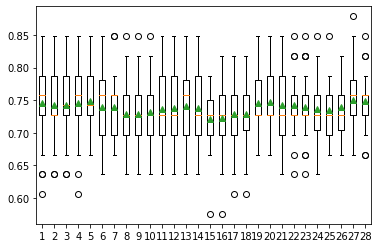

Scoring: neg_log_loss 

Columnas eliminadas : [7]
Precision: -0.548 (0.073)
Columnas eliminadas : [7, 10]
Precision: -0.543 (0.072)
Columnas eliminadas : [7, 10, 32]
Precision: -0.541 (0.071)
Columnas eliminadas : [7, 10, 32, 4]
Precision: -0.537 (0.070)
Columnas eliminadas : [7, 10, 32, 4, 8]
Precision: -0.534 (0.068)
Columnas eliminadas : [7, 10, 32, 4, 8, 14]
Precision: -0.535 (0.068)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11]
Precision: -0.533 (0.065)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23]
Precision: -0.533 (0.062)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16]
Precision: -0.531 (0.060)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17]
Precision: -0.530 (0.060)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2]
Precision: -0.528 (0.060)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2, 6]
Precision: -0.525 (0.059)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2, 6, 24]
Precision: -0.523 (0.059)
Columnas eli

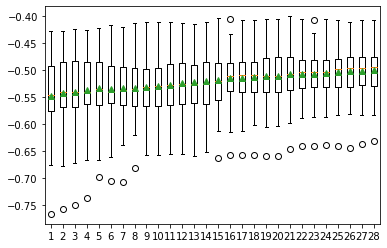

Scoring: roc_auc 

Columnas eliminadas : [7]
Precision: 0.699 (0.106)
Columnas eliminadas : [7, 10]
Precision: 0.707 (0.104)
Columnas eliminadas : [7, 10, 32]
Precision: 0.710 (0.105)
Columnas eliminadas : [7, 10, 32, 4]
Precision: 0.715 (0.105)
Columnas eliminadas : [7, 10, 32, 4, 8]
Precision: 0.723 (0.104)
Columnas eliminadas : [7, 10, 32, 4, 8, 14]
Precision: 0.720 (0.106)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11]
Precision: 0.721 (0.100)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23]
Precision: 0.720 (0.097)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16]
Precision: 0.720 (0.096)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17]
Precision: 0.721 (0.096)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2]
Precision: 0.727 (0.094)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2, 6]
Precision: 0.730 (0.090)
Columnas eliminadas : [7, 10, 32, 4, 8, 14, 11, 23, 16, 17, 2, 6, 24]
Precision: 0.735 (0.094)
Columnas eliminadas : [7, 10, 

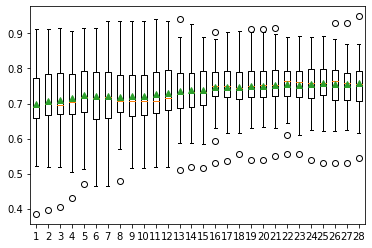

In [63]:
#Graficos con todos los scorings
ploting_all_scorings(scoring_list,top_columns_index)


###Cart Classification

Variable: 0, Score: 0.00000
Variable: 1, Score: 0.00000
Variable: 2, Score: 0.00412
Variable: 3, Score: 0.01166
Variable: 4, Score: 0.00932
Variable: 5, Score: 0.18771
Variable: 6, Score: 0.03331
Variable: 7, Score: 0.01663
Variable: 8, Score: 0.00000
Variable: 9, Score: 0.27686
Variable: 10, Score: 0.00412
Variable: 11, Score: 0.02441
Variable: 12, Score: 0.00935
Variable: 13, Score: 0.01493
Variable: 14, Score: 0.00000
Variable: 15, Score: 0.03182
Variable: 16, Score: 0.03481
Variable: 17, Score: 0.00907
Variable: 18, Score: 0.00742
Variable: 19, Score: 0.02020
Variable: 20, Score: 0.02183
Variable: 21, Score: 0.01361
Variable: 22, Score: 0.01544
Variable: 23, Score: 0.00000
Variable: 24, Score: 0.02821
Variable: 25, Score: 0.00290
Variable: 26, Score: 0.01635
Variable: 27, Score: 0.00000
Variable: 28, Score: 0.01659
Variable: 29, Score: 0.06446
Variable: 30, Score: 0.08013
Variable: 31, Score: 0.01581
Variable: 32, Score: 0.02893


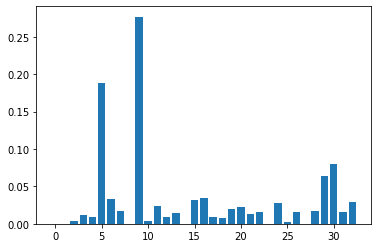

In [64]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot
scores=[]
indexes=[]

# Definimos el modelo
model = DecisionTreeClassifier()
# Entrenamos el modelo
model.fit(X_train, y_train)
# Vemos la importancia de cada variable
importance = model.feature_importances_

# Presentamos la importancia de cada variable
for i,v in enumerate(importance):
    print('Variable: {}, Score: {:.5f}'.format(i,v))
    scores.append(abs(v))
    indexes.append(i)

# Dibujamos la importancia para comparar visualmente
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [65]:
#Lista ordenada de menor a mayor importancia
top_number=28
top_columns_index=top_columns(top_number,scores,indexes,importance)

{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0028974771441240914, 7: 0.004123127669263622, 8: 0.004123127669263622, 9: 0.007421629804674522, 10: 0.00907088087237997, 11: 0.009316177645282366, 12: 0.009346466331647506, 13: 0.011663821053692276, 14: 0.013611404658331994, 15: 0.014928565699057967, 16: 0.015442409703610955, 17: 0.01580532273217722, 18: 0.01634525611743793, 19: 0.01658577408368735, 20: 0.016629948266029943, 21: 0.02020332557939175, 22: 0.021828536945794837, 23: 0.02441450850046649, 24: 0.028214646965376292, 25: 0.02892734015578605, 26: 0.03181516046336226, 27: 0.033312087769484494, 28: 0.03481498494518719, 29: 0.06445879479937063, 30: 0.08013443518625986, 31: 0.18770867395356466, 32: 0.27685611528529414}
 Variable: 0 Score: 0.0 
 Variable: 1 Score: 0.0 
 Variable: 8 Score: 0.0 
 Variable: 14 Score: 0.0 
 Variable: 23 Score: 0.0 
 Variable: 27 Score: 0.0 
 Variable: 25 Score: 0.0028974771441240914 
 Variable: 2 Score: 0.004123127669263622 
 Variable: 2 Score: 0.0041

Scoring: accuracy 

Columnas eliminadas : [0]
Precision: 0.791 (0.065)
Columnas eliminadas : [0, 1]
Precision: 0.781 (0.063)
Columnas eliminadas : [0, 1, 8]
Precision: 0.801 (0.057)
Columnas eliminadas : [0, 1, 8, 14]
Precision: 0.801 (0.062)
Columnas eliminadas : [0, 1, 8, 14, 23]
Precision: 0.778 (0.064)
Columnas eliminadas : [0, 1, 8, 14, 23, 27]
Precision: 0.797 (0.059)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25]
Precision: 0.787 (0.062)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2]
Precision: 0.794 (0.059)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2]
Precision: 0.783 (0.060)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18]
Precision: 0.789 (0.051)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17]
Precision: 0.791 (0.051)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17, 4]
Precision: 0.797 (0.060)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17, 4, 12]
Precision: 0.799 (0.050)
Columnas eliminadas : [0, 1, 8, 14, 23, 2

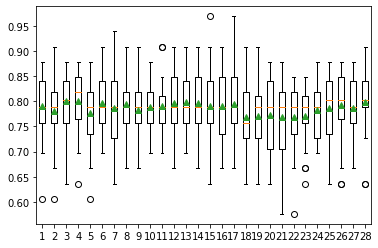

Scoring: neg_log_loss 

Columnas eliminadas : [0]
Precision: -6.768 (1.725)
Columnas eliminadas : [0, 1]
Precision: -6.699 (2.086)
Columnas eliminadas : [0, 1, 8]
Precision: -7.117 (2.135)
Columnas eliminadas : [0, 1, 8, 14]
Precision: -7.466 (2.289)
Columnas eliminadas : [0, 1, 8, 14, 23]
Precision: -7.187 (1.906)
Columnas eliminadas : [0, 1, 8, 14, 23, 27]
Precision: -7.396 (2.276)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25]
Precision: -7.431 (2.047)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2]
Precision: -7.361 (2.379)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2]
Precision: -7.257 (2.075)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18]
Precision: -7.117 (2.152)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17]
Precision: -6.908 (2.015)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17, 4]
Precision: -7.257 (1.966)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17, 4, 12]
Precision: -6.978 (2.082)
Columnas eliminadas : [0

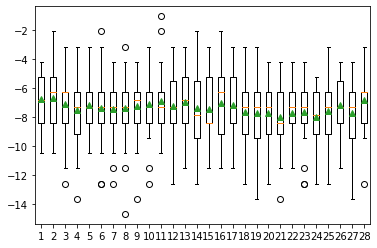

Scoring: roc_auc 

Columnas eliminadas : [0]
Precision: 0.746 (0.074)
Columnas eliminadas : [0, 1]
Precision: 0.738 (0.091)
Columnas eliminadas : [0, 1, 8]
Precision: 0.739 (0.086)
Columnas eliminadas : [0, 1, 8, 14]
Precision: 0.735 (0.087)
Columnas eliminadas : [0, 1, 8, 14, 23]
Precision: 0.734 (0.094)
Columnas eliminadas : [0, 1, 8, 14, 23, 27]
Precision: 0.741 (0.084)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25]
Precision: 0.734 (0.088)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2]
Precision: 0.727 (0.082)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2]
Precision: 0.729 (0.083)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18]
Precision: 0.741 (0.069)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17]
Precision: 0.728 (0.069)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17, 4]
Precision: 0.752 (0.072)
Columnas eliminadas : [0, 1, 8, 14, 23, 27, 25, 2, 2, 18, 17, 4, 12]
Precision: 0.735 (0.080)
Columnas eliminadas : [0, 1, 8, 14, 23, 27

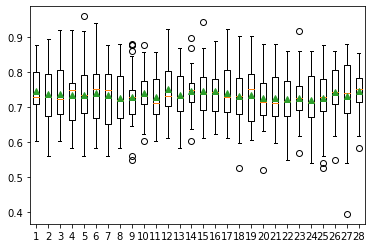

In [66]:
#Graficos con todos los scorings
ploting_all_scorings(scoring_list,top_columns_index)


###Random Forest Classifier

Variable: 0, Score: 0.01105
Variable: 1, Score: 0.01353
Variable: 2, Score: 0.00632
Variable: 3, Score: 0.02185
Variable: 4, Score: 0.03147
Variable: 5, Score: 0.05815
Variable: 6, Score: 0.02216
Variable: 7, Score: 0.00690
Variable: 8, Score: 0.01276
Variable: 9, Score: 0.17917
Variable: 10, Score: 0.01483
Variable: 11, Score: 0.02057
Variable: 12, Score: 0.02293
Variable: 13, Score: 0.01877
Variable: 14, Score: 0.01174
Variable: 15, Score: 0.02903
Variable: 16, Score: 0.03441
Variable: 17, Score: 0.03953
Variable: 18, Score: 0.03627
Variable: 19, Score: 0.01288
Variable: 20, Score: 0.04408
Variable: 21, Score: 0.01958
Variable: 22, Score: 0.02523
Variable: 23, Score: 0.02349
Variable: 24, Score: 0.03679
Variable: 25, Score: 0.01099
Variable: 26, Score: 0.01140
Variable: 27, Score: 0.01514
Variable: 28, Score: 0.03757
Variable: 29, Score: 0.03994
Variable: 30, Score: 0.05381
Variable: 31, Score: 0.04821
Variable: 32, Score: 0.02945


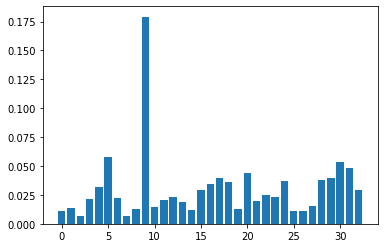

In [67]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot
scores=[]
indexes=[]
# Definimos el modelo
model = RandomForestClassifier()
# Entrenamos el modelo
model.fit(X_train, y_train)
# Vemos la importancia de cada variable
importance = model.feature_importances_
# Presentamos la importancia de cada variable
for i,v in enumerate(importance):
    print('Variable: {}, Score: {:.5f}'.format(i,v))
    scores.append(abs(v))
    indexes.append(i)
# Dibujamos la importancia para comparar visualmente
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [68]:
#Lista ordenada de menor a mayor importancia de columnas
top_number=28
top_columns_index=top_columns(top_number,scores,indexes,importance)
remaining_columns_forest=[i for i in range (len(importance)) if i not in top_columns_index]

{0: 0.006318297867113729, 1: 0.006902637481246574, 2: 0.010985249018771473, 3: 0.011051008375072367, 4: 0.011397880854009137, 5: 0.011743810779883117, 6: 0.012761933562855295, 7: 0.012881075475061328, 8: 0.013532778007360035, 9: 0.014834662408350312, 10: 0.015136328306303563, 11: 0.01877474513786475, 12: 0.019575188961443103, 13: 0.020567414503680798, 14: 0.021848371747103554, 15: 0.022162457084770663, 16: 0.0229253673968404, 17: 0.023494823645071113, 18: 0.025228750079698457, 19: 0.029028731870820116, 20: 0.02945190534969247, 21: 0.03146826275419164, 22: 0.03441148930649195, 23: 0.03626702128851754, 24: 0.03678950784903093, 25: 0.03756844767589076, 26: 0.03953052340070672, 27: 0.039935561434279544, 28: 0.04408299554467334, 29: 0.04821471367608297, 30: 0.05380549737324376, 31: 0.0581540874169178, 32: 0.1791684743669607}
 Variable: 2 Score: 0.006318297867113729 
 Variable: 7 Score: 0.006902637481246574 
 Variable: 25 Score: 0.010985249018771473 
 Variable: 0 Score: 0.011051008375072367 

Scoring: accuracy 

Columnas eliminadas : [2]
Precision: 0.753 (0.045)
Columnas eliminadas : [2, 7]
Precision: 0.763 (0.040)
Columnas eliminadas : [2, 7, 25]
Precision: 0.755 (0.048)
Columnas eliminadas : [2, 7, 25, 0]
Precision: 0.755 (0.047)
Columnas eliminadas : [2, 7, 25, 0, 26]
Precision: 0.760 (0.056)
Columnas eliminadas : [2, 7, 25, 0, 26, 14]
Precision: 0.756 (0.049)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8]
Precision: 0.760 (0.064)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19]
Precision: 0.764 (0.040)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1]
Precision: 0.763 (0.043)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10]
Precision: 0.758 (0.043)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27]
Precision: 0.759 (0.042)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27, 13]
Precision: 0.772 (0.052)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27, 13, 21]
Precision: 0.769 (0.051)
Columnas eliminadas : [2, 7, 25, 0, 26,

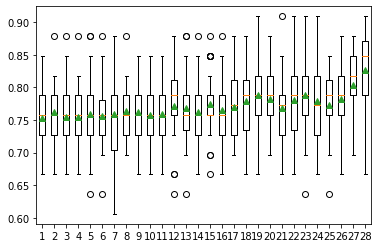

Scoring: neg_log_loss 

Columnas eliminadas : [2]
Precision: -0.482 (0.039)
Columnas eliminadas : [2, 7]
Precision: -0.480 (0.044)
Columnas eliminadas : [2, 7, 25]
Precision: -0.475 (0.043)
Columnas eliminadas : [2, 7, 25, 0]
Precision: -0.474 (0.040)
Columnas eliminadas : [2, 7, 25, 0, 26]
Precision: -0.473 (0.043)
Columnas eliminadas : [2, 7, 25, 0, 26, 14]
Precision: -0.476 (0.041)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8]
Precision: -0.471 (0.044)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19]
Precision: -0.464 (0.055)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1]
Precision: -0.469 (0.044)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10]
Precision: -0.466 (0.044)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27]
Precision: -0.463 (0.049)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27, 13]
Precision: -0.464 (0.049)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27, 13, 21]
Precision: -0.461 (0.051)
Columnas eliminadas : 

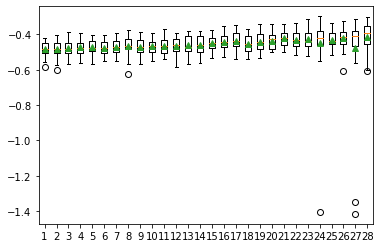

Scoring: roc_auc 

Columnas eliminadas : [2]
Precision: 0.798 (0.082)
Columnas eliminadas : [2, 7]
Precision: 0.813 (0.072)
Columnas eliminadas : [2, 7, 25]
Precision: 0.805 (0.072)
Columnas eliminadas : [2, 7, 25, 0]
Precision: 0.808 (0.067)
Columnas eliminadas : [2, 7, 25, 0, 26]
Precision: 0.808 (0.086)
Columnas eliminadas : [2, 7, 25, 0, 26, 14]
Precision: 0.815 (0.081)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8]
Precision: 0.817 (0.064)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19]
Precision: 0.822 (0.074)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1]
Precision: 0.817 (0.073)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10]
Precision: 0.818 (0.068)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27]
Precision: 0.819 (0.074)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27, 13]
Precision: 0.822 (0.076)
Columnas eliminadas : [2, 7, 25, 0, 26, 14, 8, 19, 1, 10, 27, 13, 21]
Precision: 0.828 (0.064)
Columnas eliminadas : [2, 7, 25, 0, 26, 

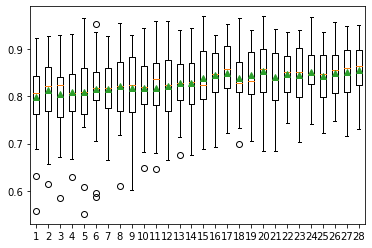

In [69]:
#Graficos con todos los scorings
ploting_all_scorings(scoring_list,top_columns_index)

###XGB

Variable: 0, Score: 0.03227
Variable: 1, Score: 0.01430
Variable: 2, Score: 0.02454
Variable: 3, Score: 0.02359
Variable: 4, Score: 0.02021
Variable: 5, Score: 0.08968
Variable: 6, Score: 0.02080
Variable: 7, Score: 0.00196
Variable: 8, Score: 0.02601
Variable: 9, Score: 0.24756
Variable: 10, Score: 0.03115
Variable: 11, Score: 0.02545
Variable: 12, Score: 0.01901
Variable: 13, Score: 0.02617
Variable: 14, Score: 0.03249
Variable: 15, Score: 0.02794
Variable: 16, Score: 0.02238
Variable: 17, Score: 0.02810
Variable: 18, Score: 0.02040
Variable: 19, Score: 0.01010
Variable: 20, Score: 0.01769
Variable: 21, Score: 0.01817
Variable: 22, Score: 0.01979
Variable: 23, Score: 0.01730
Variable: 24, Score: 0.02083
Variable: 25, Score: 0.00673
Variable: 26, Score: 0.02336
Variable: 27, Score: 0.00793
Variable: 28, Score: 0.01999
Variable: 29, Score: 0.02999
Variable: 30, Score: 0.02925
Variable: 31, Score: 0.02568
Variable: 32, Score: 0.01918


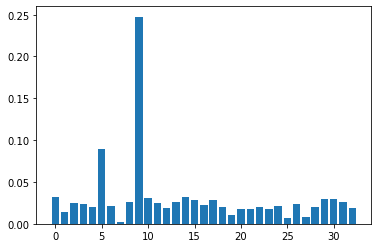

In [70]:
from sklearn.datasets import make_classification
from xgboost import XGBClassifier
from matplotlib import pyplot
scores=[]
indexes=[]

# Definimos el modelo
model = XGBClassifier()
# Entrenamos el modelo
model.fit(X_train, y_train)
# Vemos la importancia de cada variable
importance = model.feature_importances_

# Presentamos la importancia de cada variable
for i,v in enumerate(importance):
    print('Variable: {}, Score: {:.5f}'.format(i,v))
    scores.append(abs(v))
    indexes.append(i)

# Dibujamos la importancia para comparar visualmente
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [71]:
#Lista ordenada de menor a mayor importancia
top_number=28
top_columns_index_xgb=top_columns(top_number,scores,indexes,importance)

{0: 0.0019583225, 1: 0.0067252056, 2: 0.007928101, 3: 0.010097504, 4: 0.014296438, 5: 0.017297674, 6: 0.017688673, 7: 0.018170007, 8: 0.019009393, 9: 0.01918486, 10: 0.01979115, 11: 0.019985825, 12: 0.020213062, 13: 0.020403992, 14: 0.02079741, 15: 0.020826599, 16: 0.02238383, 17: 0.023362743, 18: 0.023591705, 19: 0.024543533, 20: 0.02544706, 21: 0.025684947, 22: 0.026006812, 23: 0.026173005, 24: 0.027943632, 25: 0.028097715, 26: 0.029251406, 27: 0.029988937, 28: 0.031150056, 29: 0.032270666, 30: 0.032493226, 31: 0.089676864, 32: 0.24755964}
 Variable: 7 Score: 0.0019583224784582853 
 Variable: 25 Score: 0.006725205574184656 
 Variable: 27 Score: 0.007928101345896721 
 Variable: 19 Score: 0.010097503662109375 
 Variable: 1 Score: 0.014296437613666058 
 Variable: 23 Score: 0.01729767397046089 
 Variable: 20 Score: 0.017688672989606857 
 Variable: 21 Score: 0.018170006573200226 
 Variable: 12 Score: 0.019009392708539963 
 Variable: 32 Score: 0.019184859469532967 
 Variable: 22 Score: 0.0

Scoring: accuracy 

Columnas eliminadas : [7]
Precision: 0.821 (0.054)
Columnas eliminadas : [7, 25]
Precision: 0.827 (0.049)
Columnas eliminadas : [7, 25, 27]
Precision: 0.838 (0.047)
Columnas eliminadas : [7, 25, 27, 19]
Precision: 0.825 (0.043)
Columnas eliminadas : [7, 25, 27, 19, 1]
Precision: 0.831 (0.052)
Columnas eliminadas : [7, 25, 27, 19, 1, 23]
Precision: 0.842 (0.054)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20]
Precision: 0.843 (0.050)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21]
Precision: 0.845 (0.052)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12]
Precision: 0.853 (0.052)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32]
Precision: 0.854 (0.048)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22]
Precision: 0.847 (0.045)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28]
Precision: 0.857 (0.039)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28, 4]
Precision: 0.846 (0.053)
Columnas elimin

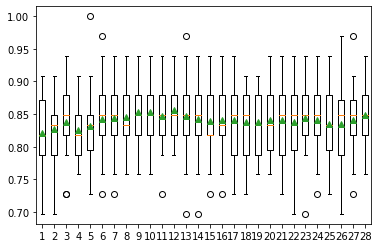

Scoring: neg_log_loss 

Columnas eliminadas : [7]
Precision: -0.391 (0.092)
Columnas eliminadas : [7, 25]
Precision: -0.389 (0.094)
Columnas eliminadas : [7, 25, 27]
Precision: -0.378 (0.090)
Columnas eliminadas : [7, 25, 27, 19]
Precision: -0.382 (0.089)
Columnas eliminadas : [7, 25, 27, 19, 1]
Precision: -0.379 (0.097)
Columnas eliminadas : [7, 25, 27, 19, 1, 23]
Precision: -0.363 (0.102)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20]
Precision: -0.362 (0.099)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21]
Precision: -0.357 (0.093)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12]
Precision: -0.348 (0.092)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32]
Precision: -0.343 (0.096)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22]
Precision: -0.345 (0.088)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28]
Precision: -0.337 (0.085)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28, 4]
Precision: -0.380 (0.100

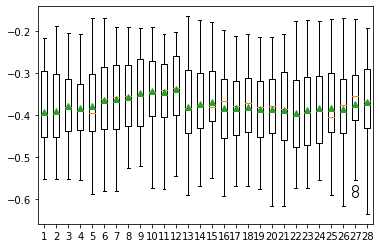

Scoring: roc_auc 

Columnas eliminadas : [7]
Precision: 0.873 (0.055)
Columnas eliminadas : [7, 25]
Precision: 0.874 (0.055)
Columnas eliminadas : [7, 25, 27]
Precision: 0.880 (0.051)
Columnas eliminadas : [7, 25, 27, 19]
Precision: 0.879 (0.053)
Columnas eliminadas : [7, 25, 27, 19, 1]
Precision: 0.877 (0.059)
Columnas eliminadas : [7, 25, 27, 19, 1, 23]
Precision: 0.890 (0.058)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20]
Precision: 0.882 (0.059)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21]
Precision: 0.887 (0.058)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12]
Precision: 0.894 (0.056)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32]
Precision: 0.899 (0.060)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22]
Precision: 0.896 (0.054)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28]
Precision: 0.905 (0.050)
Columnas eliminadas : [7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28, 4]
Precision: 0.871 (0.071)
Columnas elimina

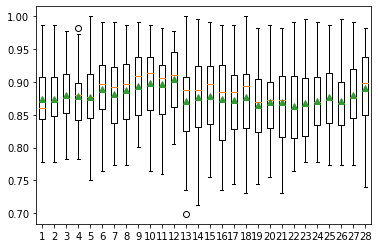

In [72]:
#Graficos con todos los scorings
ploting_all_scorings(scoring_list,top_columns_index_xgb)

In [80]:
top_columns_index_xgb.pop()
top_columns_index_xgb.pop()
top_columns_index_xgb.pop()
print(top_columns_index_xgb)

[7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28, 4]


###Permutación para clasificación

Variable: 0, Score: 0.00209
Variable: 1, Score: 0.00239
Variable: 2, Score: 0.00448
Variable: 3, Score: -0.00716
Variable: 4, Score: -0.00627
Variable: 5, Score: -0.00567
Variable: 6, Score: -0.00209
Variable: 7, Score: -0.00716
Variable: 8, Score: -0.00090
Variable: 9, Score: 0.02299
Variable: 10, Score: 0.00388
Variable: 11, Score: -0.00299
Variable: 12, Score: -0.00209
Variable: 13, Score: -0.00179
Variable: 14, Score: -0.00448
Variable: 15, Score: -0.00866
Variable: 16, Score: -0.00836
Variable: 17, Score: -0.00627
Variable: 18, Score: -0.00746
Variable: 19, Score: 0.00060
Variable: 20, Score: -0.00478
Variable: 21, Score: 0.00030
Variable: 22, Score: 0.00000
Variable: 23, Score: 0.00657
Variable: 24, Score: -0.00896
Variable: 25, Score: -0.00358
Variable: 26, Score: -0.00269
Variable: 27, Score: -0.00119
Variable: 28, Score: -0.00746
Variable: 29, Score: -0.00925
Variable: 30, Score: -0.00925
Variable: 31, Score: -0.00418
Variable: 32, Score: 0.00388


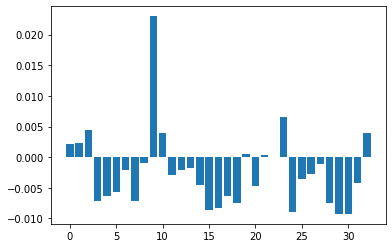

In [74]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from matplotlib import pyplot
scores=[]
indexes=[]

# Definimos el modelo
model = KNeighborsClassifier()
# Entrenamos el modelo
model.fit(X_train, y_train)
# Definimos la funcion de permutacion
results = permutation_importance(model, X_train, y_train, scoring='accuracy')
# Vemos la importancia de cada variable
importance = results.importances_mean
# Presentamos la importancia de cada variable
for i,v in enumerate(importance):
    print('Variable: {}, Score: {:.5f}'.format(i,v))
    scores.append(abs(v))
    indexes.append(i)
# Dibujamos la importancia para comparar visualmente
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [75]:
#Lista ordenada de menor a mayor importancia de columnas
top_number=28
top_columns_index=top_columns(top_number,scores,indexes,importance)


{0: 0.0, 1: 0.00029850746268655914, 2: 0.0005970149253731183, 3: 0.0008955223880596997, 4: 0.001194029850746281, 5: 0.0017910447761194214, 6: 0.0020895522388059582, 7: 0.002089552238805981, 8: 0.002089552238805981, 9: 0.00238805970149254, 10: 0.002686567164179121, 11: 0.0029850746268656803, 12: 0.003582089552238843, 13: 0.0038805970149253578, 14: 0.0038805970149253578, 15: 0.004179104477611962, 16: 0.004477611940298498, 17: 0.004477611940298521, 18: 0.00477611940298508, 19: 0.0056716417910448015, 20: 0.00626865671641792, 21: 0.0062686567164179415, 22: 0.006567164179104479, 23: 0.007164179104477619, 24: 0.007164179104477619, 25: 0.007462686567164178, 26: 0.007462686567164201, 27: 0.008358208955223923, 28: 0.00865671641791046, 29: 0.008955223880597041, 30: 0.009253731343283578, 31: 0.0092537313432836, 32: 0.022985074626865654}
 Variable: 22 Score: 0.0 
 Variable: 21 Score: 0.00029850746268655914 
 Variable: 19 Score: 0.0005970149253731183 
 Variable: 8 Score: -0.0008955223880596997 
 Var

Scoring: accuracy 

Columnas eliminadas : [22]
Precision: 0.704 (0.041)
Columnas eliminadas : [22, 21]
Precision: 0.714 (0.041)
Columnas eliminadas : [22, 21, 19]
Precision: 0.708 (0.045)
Columnas eliminadas : [22, 21, 19, 8]
Precision: 0.691 (0.045)
Columnas eliminadas : [22, 21, 19, 8, 27]
Precision: 0.697 (0.059)
Columnas eliminadas : [22, 21, 19, 8, 27, 13]
Precision: 0.692 (0.056)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0]
Precision: 0.698 (0.042)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6]
Precision: 0.703 (0.054)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6]
Precision: 0.703 (0.054)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1]
Precision: 0.702 (0.062)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26]
Precision: 0.695 (0.063)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26, 11]
Precision: 0.707 (0.050)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26, 11, 25]
Precision: 0.702 (0.041)
Columnas eliminadas : [2

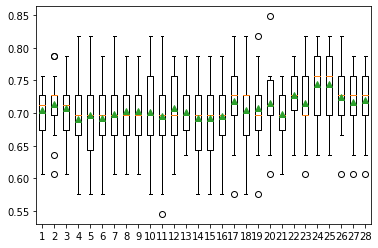

Scoring: neg_log_loss 

Columnas eliminadas : [22]
Precision: -2.908 (1.336)
Columnas eliminadas : [22, 21]
Precision: -2.644 (1.163)
Columnas eliminadas : [22, 21, 19]
Precision: -2.615 (1.244)
Columnas eliminadas : [22, 21, 19, 8]
Precision: -3.074 (1.511)
Columnas eliminadas : [22, 21, 19, 8, 27]
Precision: -2.598 (1.234)
Columnas eliminadas : [22, 21, 19, 8, 27, 13]
Precision: -2.695 (1.098)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0]
Precision: -2.505 (1.343)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6]
Precision: -2.098 (1.111)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6]
Precision: -2.098 (1.111)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1]
Precision: -2.294 (1.130)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26]
Precision: -2.255 (0.986)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26, 11]
Precision: -2.323 (1.077)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26, 11, 25]
Precision: -2.201 (1.154)
Columna

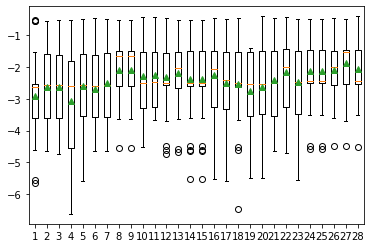

Scoring: roc_auc 

Columnas eliminadas : [22]
Precision: 0.497 (0.091)
Columnas eliminadas : [22, 21]
Precision: 0.495 (0.092)
Columnas eliminadas : [22, 21, 19]
Precision: 0.500 (0.103)
Columnas eliminadas : [22, 21, 19, 8]
Precision: 0.498 (0.106)
Columnas eliminadas : [22, 21, 19, 8, 27]
Precision: 0.532 (0.099)
Columnas eliminadas : [22, 21, 19, 8, 27, 13]
Precision: 0.529 (0.090)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0]
Precision: 0.523 (0.082)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6]
Precision: 0.560 (0.077)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6]
Precision: 0.560 (0.077)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1]
Precision: 0.557 (0.092)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26]
Precision: 0.557 (0.106)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26, 11]
Precision: 0.557 (0.102)
Columnas eliminadas : [22, 21, 19, 8, 27, 13, 0, 6, 6, 1, 26, 11, 25]
Precision: 0.546 (0.096)
Columnas eliminadas : [22

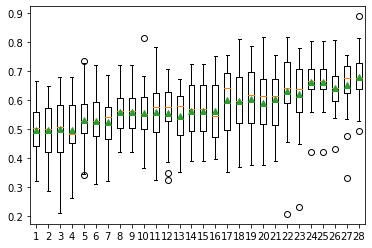

In [76]:
#Graficos con todos los scorings
ploting_all_scorings(scoring_list,top_columns_index)

###Comparación de resultados

En nuestro caso particular los mejores resultados son los que vienen dados cuando se usa un XGboost y se eliminan las columnas 7, 25, 27, 19, 1, 23, 20, 21, 12, 32, 22, 28, 4. Se obtiene una precisión del (85.7% ± 0.039%)

## Modelos

###XGBoost

Dado que el método que más precisión nos dió en la sección de antes fue el de XGB, es ese el que utilizaremos para nuestro análisis y también será este el modelo que afinaremos. 

####Modelo con selección de variables y sin afinar

Sin afinar el modelo se puede observar que para las columnas seleccionadas en la sección anterior se obtiene una precisión en las predicciones del 85.5 % en el conjunto de test.

In [81]:
from xgboost import XGBClassifier

X_new=np.delete(X,top_columns_index_xgb, axis=1)
# Se separa el trainig set y el test set 
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=1)
# Se escalan los resultados
X_train,X_test=scaler_function(X_train,X_test)
#Apliquem un model
model = XGBClassifier()
# Entrenem el model
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
#mirem la precisió
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_train, y_train, scoring=scoring_list[0], cv=cv, n_jobs=-1)
print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')
print('Accuracy {} %'.format(100*accuracy_score(y_test, y_pred)))


Precision: 0.818 (0.044)
Accuracy 85.5 %


In [ ]:
a=pd.DataFrame(X_train)
a

####Optimización de hiperparámetros

Vamos a optimizar los hiperparámetros usando un GridSearch y lo haremos en varias rondas para así tener un modelo más preciso donde después de cada ronda podamos reafinar los parámetros en función de los parámetros obtenidos previamente. Los parámetros que se han escogido para afinar son max_depth, learning_rate, gamma, reg_lambda, scale_pos_weight, subsample, colsample_bytree ya que hemos visto en varias fuentes que estos parámetros son relevantes para este modelo. En la tercera ronda también se afina el parámetro n_estimators. Los valores de los parámetros se han escogido basándose en https://towardsdatascience.com/beginners-guide-to-xgboost-for-classification-problems-50f75aac5390


#####Primera ronda

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "max_depth": [3, 4, 5, 7],
    "learning_rate": [0.1, 0.01, 0.05,0.001],
    "gamma": [0, 0.25,0.5,1],
    "reg_lambda": [0, 1, 10],
    "scale_pos_weight": [1, 3, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.5],
}

        
grid_search = GridSearchCV(estimator = model,
                           param_grid = parameters, 
                           scoring = 'accuracy',
                           cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=1),
                           n_jobs = -1)

grid_search = grid_search.fit(X_train, y_train)

best_accuracy = grid_search.best_score_

best_parameters = grid_search.best_params_

In [ ]:
print(best_accuracy)
print(best_parameters)
print(grid_search.score(X_train, y_train))

0.8441703509710607
{'colsample_bytree': 0.5, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 3, 'reg_lambda': 10, 'scale_pos_weight': 3, 'subsample': 0.8}
0.84625


In [ ]:
from xgboost import XGBClassifier
#Apliquem el XGBoostClassifier
model = XGBClassifier(colsample_bytree=0.5,gamma=0.5,learning_rate=0.05,max_depth=3,reg_lambda=10,scale_pos_weight=3,subsample=0.8)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')
print('Accuracy {} %'.format(100*accuracy_score(y_test, y_pred)))

Precision: 0.844 (0.045)
Accuracy 89.0 %


#####Segunda ronda

In [ ]:
from sklearn.model_selection import GridSearchCV
#Volvemos a afinar el modelo
parameters = {
    "max_depth": [3, 4],
    "learning_rate": [0.08, 0.05, 0.03,0.01],
    "gamma": [0.3,0.5,0.7,0.9,1.5],
    "reg_lambda": [ 10,20,50],
    "scale_pos_weight": [3, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.5],
}

              
grid_search = GridSearchCV(estimator = model,
                           param_grid = parameters, 
                           scoring = 'accuracy',
                           cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=1),
                           n_jobs = -1)

grid_search = grid_search.fit(X_train, y_train)

best_accuracy = grid_search.best_score_

best_parameters = grid_search.best_params_

In [ ]:
print(best_accuracy)
print(best_parameters)
print(grid_search.score(X_train, y_train))

0.8454172259612828
{'colsample_bytree': 0.5, 'gamma': 0.3, 'learning_rate': 0.05, 'max_depth': 3, 'reg_lambda': 20, 'scale_pos_weight': 3, 'subsample': 0.8}
0.845


In [ ]:
from xgboost import XGBClassifier
#Apliquem el XGBoostClassifier
model = XGBClassifier(colsample_bytree=0.5,gamma=0.3,learning_rate=0.05,max_depth=3,reg_lambda=20,scale_pos_weight=3,subsample=0.8)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')
print('Accuracy {} %'.format(100*accuracy_score(y_test, y_pred)))

Precision: 0.845 (0.044)
Accuracy 89.0 %


#####Tercera ronda

In [ ]:
from sklearn.model_selection import GridSearchCV
#Volvemos a afinar el modelo
parameters = {
    "max_depth": [3, 4],
    "learning_rate": [0.08, 0.05, 0.03,0.01],
    "gamma": [0.1,0.2,0.3,0.5],
    "reg_lambda": [ 15,20,30],
    "scale_pos_weight": [2,3, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.5],
    "n_estimators":[75,100,150]
}

              
grid_search = GridSearchCV(estimator = model,
                           param_grid = parameters, 
                           scoring = 'accuracy',
                           cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=1),
                           n_jobs = -1)

grid_search = grid_search.fit(X_train, y_train)

best_accuracy = grid_search.best_score_

best_parameters = grid_search.best_params_

In [ ]:
print(best_accuracy)
print(best_parameters)
print(grid_search.score(X_train, y_train))

0.8429172181389805
{'colsample_bytree': 0.5, 'gamma': 0.2, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 150, 'reg_lambda': 15, 'scale_pos_weight': 3, 'subsample': 0.8}
0.84625


In [ ]:
from xgboost import XGBClassifier
#Apliquem el XGBoostClassifier
model = XGBClassifier(colsample_bytree=0.5,gamma=0.2,learning_rate=0.03,max_depth=3,reg_lambda=15,scale_pos_weight=3,subsample=0.8,n_estimators=150)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
print(f'Precision: {np.mean(n_scores):.3f} ({np.std(n_scores):.3f})')
print('Accuracy {} %'.format(100*accuracy_score(y_test, y_pred)))

Precision: 0.844 (0.044)
Accuracy 89.0 %


####Conclusiones y resultados

Después de la tercera ronda de afinamiento, se ha decidido desistir de afinar más ya que no se observa una mejoría en la precisión del modelo. Por lo tanto, los resultados finales con los mejores parámetros son :
'colsample_bytree': 0.5, 'gamma': 0.2, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 150, 'reg_lambda': 15, 'scale_pos_weight': 3, 'subsample': 0.8 .
Usando estos parámetros se obtiene una precisión de un 89% en el conjunto de test. 

##Modelo Deep Learning


En esta última parte vamos a crear un modelo que use redes neuronales para hacer las predicciones. Para ello, primero importaremos Keras y las librerias necesarias, luego inicializaremos la red neuronal, añadiremos las capas necesarias, ajustaremos el modelo a nuestro conjunto X_train y finalmente evaluaremos el modelo y veremos que tan preciso es.

###Carga de las librerias y incialización de la RNA

In [82]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [83]:
a=pd.DataFrame(X_train)
a

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.0,1.0,1.000000,0.473684,0.2,0.500000,0.333333,0.75,0.166667,0.333333,1.000000,0.692308,0.921053,0.235908,0.186047,0.652174,0.0,0.260197,0.234474,0.487860
1,0.5,1.0,0.333333,0.157895,0.6,0.166667,0.333333,0.50,0.666667,0.333333,1.000000,0.461538,0.263158,0.294363,0.209302,0.260870,0.5,0.025316,0.045627,0.060259
2,0.5,1.0,0.333333,0.315789,0.4,0.000000,0.333333,1.00,0.166667,0.333333,1.000000,0.153846,0.578947,0.480167,0.511628,0.000000,0.0,0.243319,0.438530,0.456158
3,1.0,1.0,0.166667,0.578947,0.0,0.000000,0.000000,0.25,1.000000,0.000000,0.000000,0.076923,0.105263,0.741127,0.604651,0.826087,1.0,0.294421,0.265315,0.631149
4,0.0,0.0,1.000000,0.842105,0.2,0.500000,0.666667,0.00,1.000000,1.000000,0.333333,0.076923,0.131579,0.010438,0.116279,0.956522,0.5,0.751055,0.676806,0.704491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.0,0.0,0.666667,0.631579,0.0,0.000000,0.000000,0.00,0.166667,1.000000,0.000000,0.538462,0.947368,0.528184,0.581395,0.478261,0.0,0.275199,0.495986,0.589886
796,1.0,0.0,0.000000,0.684211,0.0,0.500000,0.333333,0.00,0.000000,0.000000,0.000000,0.230769,0.657895,0.415449,0.465116,0.434783,0.5,0.141116,0.000000,0.339917
797,1.0,1.0,0.666667,0.000000,0.2,0.666667,0.333333,1.00,1.000000,1.000000,0.000000,0.461538,0.263158,0.594990,0.534884,0.130435,0.5,0.023441,0.021124,0.055730
798,0.5,1.0,0.833333,0.578947,0.8,1.000000,0.333333,0.25,0.166667,0.000000,0.666667,0.692308,0.921053,0.893528,0.767442,0.695652,0.5,0.598218,0.269540,0.721474


In [84]:
classifier = Sequential()

classifier.add(Dense(units = 11, kernel_initializer = "uniform",  
                     activation = "relu", input_dim = 20))

###Adición de capas ocultas y capa de salida

Se ha escogido como función de activación en la capa final la función sigmoide ya que esta es adecuada para una clasificación binaria y porque se puede interpretar como una probabilidad entre 0 y 1 de que un cliente cometa fraude. Luego en la evaluación del modelo se ha establecido un umbral de 0.5 de manera que si el resultado devuelto por la neurona de la capa final es mayor que 0.5 entonces el output será 1 y 0 en caso de ser menor que 0.5.  

In [85]:
classifier.add(Dense(units = 11, kernel_initializer = "uniform",  activation = "relu"))


In [86]:
classifier.add(Dense(units = 1, kernel_initializer = "uniform",  activation = "sigmoid"))

###Compilación de la RNA y ajuste al conjunto de entrenamiento

In [87]:
classifier.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [91]:
classifier.fit(X_train, y_train,  batch_size = 10, epochs = 100)

Epoch 1/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4560 - accuracy: 0.8062
Epoch 2/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4568 - accuracy: 0.7975
Epoch 3/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4556 - accuracy: 0.8000
Epoch 4/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4557 - accuracy: 0.7962
Epoch 5/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4550 - accuracy: 0.8012
Epoch 6/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4548 - accuracy: 0.7987
Epoch 7/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4553 - accuracy: 0.7975
Epoch 8/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4557 - accuracy: 0.7987
Epoch 9/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4565 - accuracy: 0.7925
Epoch 10/100
80/80 [==============================] - 0s 2ms/step - loss: 0.4551 - accuracy: 0.7987
Epoch 11/

###Evaluación de los modelos y cálculo de predicciones finales


In [93]:
y_pred  = classifier.predict(X_test)
y_pred = (y_pred>0.5)

In [94]:
from sklearn.metrics import confusion_matrix,classification_report
print('Accuracy {} %'.format(100*accuracy_score(y_test, y_pred)))

Accuracy 78.0 %


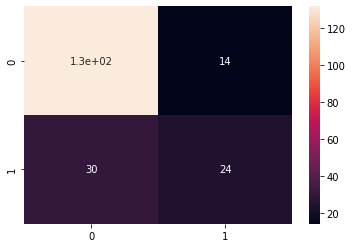

In [95]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.90      0.86       146
         1.0       0.63      0.44      0.52        54

    accuracy                           0.78       200
   macro avg       0.72      0.67      0.69       200
weighted avg       0.77      0.78      0.77       200



Al usar ANN, los mejores resultados son del 81% aproximadamente. Ese es el mejor resultado que se ha obtenido. Se ha comprobado que si se intenta entrenar más al modelo este se ajusta mejor a los datos de entrenamiento pero no se ajusta tan bien a los de test debido al overfitting. Haría falta un estudio más profundo y continuar variando diversos parámetros como el número de capas ,el número de neuronas en cada capa o la función de activación en cada capa para ver si se pueden obtener mejores resultados. 

Finalmente, si se compara la precisión de este método con el XGB se ve que el XGB es superior. Una posible causa es que para entrenar un modelo con redes neuronales, se necesita una gran cantidad de datos y en este caso particular el conjunto no es demasiado grande.